### Instalasi Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from imblearn.over_sampling import SMOTE
import warnings
from pathlib import Path
import joblib
import json
from sklearn.base import clone
warnings.filterwarnings("ignore")

## **LOAD DATA DAN PENGECEKAN DATA**

### load data

In [2]:
DATA_PATH = "diabetes.csv"
data = pd.read_csv(DATA_PATH)
data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


### Pengecekan Duplikat Data

In [3]:
jumlah_duplikat = data.duplicated().sum()
print(f"Jumlah data duplikat: {jumlah_duplikat}")

Jumlah data duplikat: 0


### Pengecekan Missing Value

In [4]:
# Cek missing values dan nilai 0 d
print("\nNilai 0 pada setiap kolom:")
jumlah_nol = {}
for kolom in data.columns:
    if kolom != 'Outcome':
        hitung_nol = (data[kolom] == 0).sum()
        jumlah_nol[kolom] = hitung_nol
        print(f"{kolom}: {hitung_nol}")

# Total baris yang memiliki minimal satu nilai 0 (selain Outcome dan Pregnancies)
fitur_dengan_nol = data.drop(['Outcome', 'Pregnancies'], axis=1) == 0
total_baris_nol = fitur_dengan_nol.any(axis=1).sum()
persentase_baris_nol = (total_baris_nol / len(data)) * 100
print(f"Total baris yang memiliki minimal satu nilai 0: {total_baris_nol}")
print(f"Persentase baris dengan nilai 0: {persentase_baris_nol:.2f}%")


Nilai 0 pada setiap kolom:
Pregnancies: 111
Glucose: 5
BloodPressure: 35
SkinThickness: 227
Insulin: 374
BMI: 11
DiabetesPedigreeFunction: 0
Age: 0
Total baris yang memiliki minimal satu nilai 0: 376
Persentase baris dengan nilai 0: 48.96%


## **PREPOCESSING**

### Imputasi dengan KNNImputer

In [5]:
if jumlah_duplikat > 0:
    data = data.drop_duplicates().reset_index(drop=True)
    print(f"Data duplikat dihapus. Jumlah data setelah penghapusan: {len(data)}")
else:
    print("Tidak ada duplikat, data tetap.")

Tidak ada duplikat, data tetap.


In [6]:
kolom_hilang = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
data[kolom_hilang] = data[kolom_hilang].replace(0, np.nan)
if persentase_baris_nol > 10:
    X = data.drop(columns=["Outcome"])
    y = data["Outcome"].to_numpy()
    X_imputed = KNNImputer(n_neighbors=5).fit_transform(X)
    data = pd.DataFrame(X_imputed, columns=X.columns).assign(Outcome=y)
    print(f"Jumlah missing values setelah imputasi:\n{data.isnull().sum()}")
else:
    data = data.dropna(subset=kolom_hilang).reset_index(drop=True)
    print(f"Jumlah data setelah menghapus baris dengan nilai 0: {len(data)}")

Jumlah missing values setelah imputasi:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [7]:
data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6.0,148.0,72.0,35.0,169.0,33.6,0.627,50.0,1
1,1.0,85.0,66.0,29.0,58.6,26.6,0.351,31.0,0
2,8.0,183.0,64.0,25.8,164.6,23.3,0.672,32.0,1
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0,0
4,0.0,137.0,40.0,35.0,168.0,43.1,2.288,33.0,1
...,...,...,...,...,...,...,...,...,...
763,10.0,101.0,76.0,48.0,180.0,32.9,0.171,63.0,0
764,2.0,122.0,70.0,27.0,165.0,36.8,0.340,27.0,0
765,5.0,121.0,72.0,23.0,112.0,26.2,0.245,30.0,0
766,1.0,126.0,60.0,35.2,134.2,30.1,0.349,47.0,1


### Cek dan Penanganan Outlier

In [8]:
# ============================================================
# CEK OUTLIER dengan IQR
# ============================================================
fitur_numerik = [col for col in data.columns if col != 'Outcome']

print("=== DETEKSI OUTLIER (IQR Method) ===")
outlier_info = {}
for col in fitur_numerik:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outlier = ((data[col] < lower) | (data[col] > upper)).sum()
    outlier_info[col] = {'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
                          'Lower Bound': lower, 'Upper Bound': upper,
                          'Jumlah Outlier': n_outlier}
    print(f"{col:20s} | Lower: {lower:8.3f} | Upper: {upper:8.3f} | Outlier: {n_outlier}")

df_outlier_info = pd.DataFrame(outlier_info).T
print(f"\nTotal baris: {len(data)}")

=== DETEKSI OUTLIER (IQR Method) ===
Pregnancies          | Lower:   -6.500 | Upper:   13.500 | Outlier: 4
Glucose              | Lower:   37.125 | Upper:  202.125 | Outlier: 0
BloodPressure        | Lower:   40.000 | Upper:  104.000 | Outlier: 14
SkinThickness        | Lower:    5.000 | Upper:   53.000 | Outlier: 6
Insulin              | Lower:  -65.475 | Upper:  343.525 | Outlier: 33
BMI                  | Lower:   13.850 | Upper:   50.250 | Outlier: 8
DiabetesPedigreeFunction | Lower:   -0.330 | Upper:    1.200 | Outlier: 29
Age                  | Lower:   -1.500 | Upper:   66.500 | Outlier: 9

Total baris: 768


In [9]:
# ============================================================
# PENANGANAN OUTLIER dengan Winsorizing (Capping)
# Alasan: outlier pada data medis dapat merepresentasikan kondisi
# klinis ekstrem yang tetap informatif, sehingga tidak dihapus
# melainkan dikap pada batas IQR.
# ============================================================
data_clean = data.copy()
for col in fitur_numerik:
    Q1 = data_clean[col].quantile(0.25)
    Q3 = data_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    data_clean[col] = data_clean[col].clip(lower=lower, upper=upper)

print("Penanganan outlier (winsorizing) selesai.")
print(f"Jumlah data setelah penanganan outlier: {len(data_clean)}")
data = data_clean
data

Penanganan outlier (winsorizing) selesai.
Jumlah data setelah penanganan outlier: 768


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6.0,148.0,72.0,35.0,169.0,33.6,0.627,50.0,1
1,1.0,85.0,66.0,29.0,58.6,26.6,0.351,31.0,0
2,8.0,183.0,64.0,25.8,164.6,23.3,0.672,32.0,1
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0,0
4,0.0,137.0,40.0,35.0,168.0,43.1,1.200,33.0,1
...,...,...,...,...,...,...,...,...,...
763,10.0,101.0,76.0,48.0,180.0,32.9,0.171,63.0,0
764,2.0,122.0,70.0,27.0,165.0,36.8,0.340,27.0,0
765,5.0,121.0,72.0,23.0,112.0,26.2,0.245,30.0,0
766,1.0,126.0,60.0,35.2,134.2,30.1,0.349,47.0,1


### Normalisasi dengan MinMaxScaler

In [10]:
X = data.drop(columns=["Outcome"])
y = data["Outcome"]
min_max = MinMaxScaler()
X_ternormalisasi = min_max.fit_transform(X)
X_ternormalisasi = pd.DataFrame(X_ternormalisasi, columns=X.columns)
X_ternormalisasi

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.444444,0.670968,0.50000,0.608696,0.470374,0.480499,0.489305,0.637363
1,0.074074,0.264516,0.40625,0.478261,0.135346,0.262090,0.243316,0.219780
2,0.592593,0.896774,0.37500,0.408696,0.457021,0.159126,0.529412,0.241758
3,0.074074,0.290323,0.40625,0.347826,0.242774,0.308892,0.079323,0.000000
4,0.000000,0.600000,0.00000,0.608696,0.467339,0.776911,1.000000,0.263736
...,...,...,...,...,...,...,...,...
763,0.740741,0.367742,0.56250,0.891304,0.503755,0.458658,0.082888,0.923077
764,0.148148,0.503226,0.46875,0.434783,0.458235,0.580343,0.233512,0.131868
765,0.370370,0.496774,0.50000,0.347826,0.297398,0.249610,0.148841,0.197802
766,0.074074,0.529032,0.31250,0.613043,0.364767,0.371295,0.241533,0.571429


In [11]:
# out_dir = Path("for_deployment")
# joblib.dump(min_max, out_dir / "min_max_scaler.joblib")

### Split data

In [12]:
# ============================================================
# SECTION A: SPLIT DATA 70:30
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_ternormalisasi, y, test_size=0.3, random_state=42
)
print(f"[70:30] Jumlah data train : {len(X_train)}")
print(f"[70:30] Jumlah data test  : {len(X_test)}")

[70:30] Jumlah data train : 537
[70:30] Jumlah data test  : 231


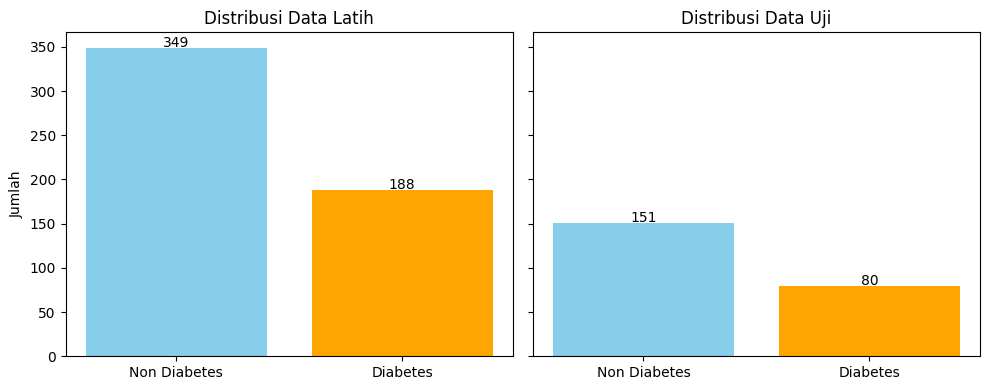

In [13]:
# distribusi kelas pada data latih dan data uji
train_y_counts = y_train.value_counts()
test_y_counts = y_test.value_counts()
test_counts  = y_test.value_counts().reindex([0, 1], fill_value=0)

labels = ["Non Diabetes", "Diabetes"]
x = [0, 1]

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

axes[0].bar(x, train_y_counts.values, color=["skyblue", "orange"])
axes[0].set_title("Distribusi Data Latih")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_ylabel("Jumlah")

axes[1].bar(x, test_counts.values, color=["skyblue", "orange"])
axes[1].set_title("Distribusi Data Uji")
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)

# angka di atas bar (opsional tapi masih sederhana)
for ax, counts in zip(axes, [train_y_counts, test_counts]):
    for i, v in enumerate(counts.values):
        ax.text(i, v + 1, str(int(v)), ha="center")

plt.tight_layout()
plt.show()

### Balancing Data

In [14]:
# balancing dengan SMOTE
jumlah_per_kelas = y_train.value_counts()
jumlah_kelas_mayoritas = jumlah_per_kelas.max()
jumlah_kelas_minoritas = jumlah_per_kelas.min()
IR = jumlah_kelas_mayoritas / jumlah_kelas_minoritas
print(f"Imbalance Ratio: {IR}")

if IR > 1.5:
    pass
    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
else:
    print("Data sudah cukup seimbang")

Imbalance Ratio: 1.8563829787234043


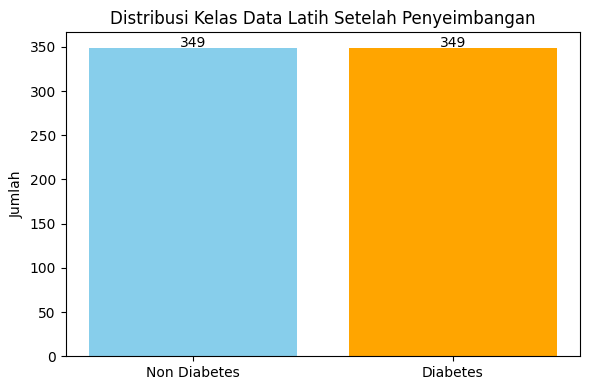

In [15]:
counts_smote =y_train_smote.value_counts()

plt.figure(figsize=(6, 4))
plt.bar([0, 1], counts_smote.values, color=["skyblue", "orange"])
plt.xticks([0, 1], ["Non Diabetes", "Diabetes"])
plt.ylabel("Jumlah")
plt.title("Distribusi Kelas Data Latih Setelah Penyeimbangan")

for i, v in enumerate(counts_smote.values):
    plt.text(i, v + 1, str(int(v)), ha="center")

plt.tight_layout()
plt.show()

## UJI COBA SKENARIO

---
# 🔵 SECTION A — PEMBAGIAN DATA 70:30

In [16]:
# Cross-validation dengan KFold
n_splits = 5
kfold = KFold(n_splits=n_splits, shuffle=True, random_state=42)
for split, (train_index, validasi_index) in enumerate(kfold.split(X_train_smote, y_train_smote), 1):
    print(f"split {split}:\n")
    print(f"Jumlah data train: {len(train_index)}")
    print(f"Jumlah data validation: {len(validasi_index)}\n")
    print(f"Train index: {', '.join(map(str, train_index))}")
    print(f"Validation index:  {', '.join(map(str, validasi_index))}\n")

split 1:

Jumlah data train: 558
Jumlah data validation: 140

Train index: 0, 1, 3, 4, 5, 7, 8, 9, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 25, 26, 27, 28, 29, 32, 33, 34, 35, 36, 37, 38, 40, 42, 43, 45, 46, 47, 48, 50, 51, 52, 53, 57, 58, 59, 61, 62, 64, 66, 67, 68, 71, 73, 74, 75, 79, 80, 82, 83, 84, 85, 87, 88, 89, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 102, 103, 104, 105, 106, 107, 111, 112, 113, 114, 115, 116, 117, 119, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 134, 137, 138, 139, 140, 141, 142, 143, 144, 146, 147, 149, 150, 151, 152, 153, 154, 156, 157, 159, 160, 161, 162, 163, 166, 167, 168, 169, 170, 171, 172, 173, 175, 177, 178, 179, 180, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 193, 194, 195, 196, 197, 198, 200, 201, 202, 203, 205, 206, 207, 210, 213, 214, 215, 216, 217, 219, 220, 221, 222, 224, 225, 226, 228, 229, 230, 231, 232, 233, 235, 236, 237, 238, 239, 240, 241, 242, 243, 245, 246, 247, 250, 251, 252, 253, 255, 257, 258, 260, 261, 262, 263

In [17]:
def plot_confusion_matrix(nama_skenario, y_asli, y_prediksi):
    judul = nama_skenario
    fig, ax = plt.subplots(figsize=(6, 5))
    cm = confusion_matrix(y_asli, y_prediksi)

    # Menambahkan annot_kws={"size": 16} untuk memperbesar angka di dalam kotak
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Non Diabetes", "Diabetes"],
                yticklabels=["Non Diabetes", "Diabetes"],
                annot_kws={"size": 18}) # <-- Angka 18 bisa kamu naik-turunkan sesuai selera

    # Memperbesar font judul dan label agar seimbang dengan angka di dalam
    ax.set_title(f"Confusion Matrix – {judul}", fontsize=14, pad=10)
    ax.set_xlabel("Prediksi", fontsize=12)
    ax.set_ylabel("Aktual", fontsize=12)

    # Memperbesar font label x dan y (Non Diabetes/Diabetes)
    ax.tick_params(axis='both', labelsize=11)

    plt.tight_layout()
    plt.show()
    plt.close(fig)

def evaluasi_testing(nama_skenario, y_asli, y_prediksi):
    judul = f"{nama_skenario}"
    akurasi = accuracy_score(y_asli, y_prediksi)
    presisi = precision_score(y_asli, y_prediksi, zero_division=0)
    recall  = recall_score(y_asli, y_prediksi, zero_division=0)
    f1      = f1_score(y_asli, y_prediksi, zero_division=0)
    print(f"  Hasil Evaluasi Testing – {judul}")
    print(f"  Akurasi  : {akurasi:.4f}")
    print(f"  Presisi  : {presisi:.4f}")
    print(f"  Recall   : {recall:.4f}")
    print(f"  F1-Score : {f1:.4f}")
    return {
        "Model"   : judul,
        "Akurasi" : round(akurasi, 4),
        "Presisi" : round(presisi, 4),
        "Recall"  : round(recall,  4),
        "F1-Score": round(f1,      4),
    }


def tampilkan_tabel_perbandingan(y_pred, y_asli, nama_skenario="Skenario", jumlah=5):
    """
    Fungsi untuk menampilkan tabel perbandingan hasil prediksi model
    dengan diagnosis asli beserta keterangan klasifikasinya.
    """
    # 1. Pastikan pengambilan data aman (berlaku untuk Pandas Series maupun Numpy Array)
    y_test_sample = y_asli.iloc[:jumlah].values if hasattr(y_asli, 'iloc') else y_asli[:jumlah]
    y_pred_sample = y_pred[:jumlah]

    # 2. Logika Keterangan (TP, TN, FP, FN)
    keterangan = []
    for pred, asli in zip(y_pred_sample, y_test_sample):
        if pred == asli:
            if asli == 1:
                keterangan.append("Tebakan Benar (True Positive)")
            else:
                keterangan.append("Tebakan Benar (True Negative)")
        else:
            if pred == 1 and asli == 0:
                keterangan.append("Tebakan Salah (False Positive)")
            elif pred == 0 and asli == 1:
                keterangan.append("Tebakan Salah (False Negative)")

    # 3. Menyusun DataFrame
    df_perbandingan = pd.DataFrame({
        f'Prediksi {nama_skenario}(y_pred)': y_pred_sample,
        f'Label Aktual(y_test)': y_test_sample,
        'Keterangan': keterangan
    })

    # 4. Menampilkan tabel
    print(f"")
    display(df_perbandingan)

### Skenario 1 (KNN)

In [18]:
import time
_t0 = time.time()
param_grid_knn = {
    "n_neighbors": [5,7,9,11,13,15,19],
    "metric": ["euclidean", "manhattan"],
    "weights": ["uniform", "distance"],
}
grid_knn = GridSearchCV(
    KNeighborsClassifier(),param_grid_knn, cv=kfold,
    scoring="accuracy",n_jobs=-1,verbose=1,
)
grid_knn.fit(X_train_smote, y_train_smote)
print(f"KNN Best Score: {grid_knn.best_score_:.4f}")
print(f"KNN Best Params: {grid_knn.best_params_}")
results_knn = pd.DataFrame(grid_knn.cv_results_)
best_idx = grid_knn.best_index_
best_idx = grid_knn.best_index_
for fold in range(kfold.get_n_splits()):
    fold_score = results_knn.loc[best_idx, f'split{fold}_test_score']
    print(f"Fold {fold+1}: {fold_score:.4f}")
print(f"Mean: {grid_knn.best_score_:.4f}")
waktu_train_knn = (time.time() - _t0) * 1000  # ms
print(f"waktu_train_knn: {waktu_train_knn:.2f} ms")

Fitting 5 folds for each of 28 candidates, totalling 140 fits
KNN Best Score: 0.8124
KNN Best Params: {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'distance'}
Fold 1: 0.7571
Fold 2: 0.8000
Fold 3: 0.8214
Fold 4: 0.8633
Fold 5: 0.8201
Mean: 0.8124
waktu_train_knn: 7789.87 ms


,Prediksi Skenario 1(y_pred),Label Aktual(y_test),Keterangan
0,1,0,Tebakan Salah (False Positive)
1,1,0,Tebakan Salah (False Positive)
2,0,0,Tebakan Benar (True Negative)
3,1,0,Tebakan Salah (False Positive)
4,1,0,Tebakan Salah (False Positive)


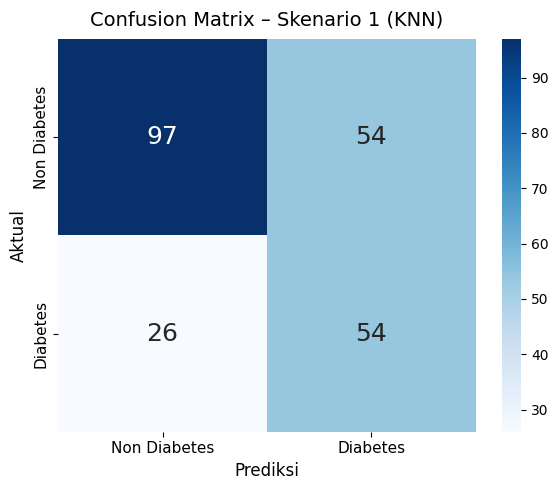

  Hasil Evaluasi Testing – Skenario 1 (KNN)
  Akurasi  : 0.6537
  Presisi  : 0.5000
  Recall   : 0.6750
  F1-Score : 0.5745
waktu_predict_knn: 6.99 ms


In [19]:
knn_final = grid_knn.best_estimator_
import time
_t0 = time.time()
y_pred_knn_final = knn_final.predict(X_test)
waktu_predict_knn = (time.time() - _t0) * 1000  # ms
tampilkan_tabel_perbandingan(y_pred_knn_final, y_test, nama_skenario="Skenario 1")
plot_confusion_matrix("Skenario 1 (KNN)", y_test, y_pred_knn_final)
hasil_knn_final = evaluasi_testing("Skenario 1 (KNN)", y_test, y_pred_knn_final)
print(f"waktu_predict_knn: {waktu_predict_knn:.2f} ms")

### Skenario 2 (LR)

In [20]:
import time
_t0 = time.time()
# membuat model Logistic Regression dengan GridSearchCV
param_grid_lr = {
    "C": np.logspace(-4, 4, 20),
    "solver": ["liblinear", "lbfgs"],
    "penalty": ["l1", "l2"],
}
grid_lr = GridSearchCV(
    LogisticRegression(random_state=42),param_grid_lr,cv=kfold,
    scoring="accuracy",n_jobs=-1,verbose=1,
)
grid_lr.fit(X_train_smote, y_train_smote)
print(f"LR Best Score: {grid_lr.best_score_:.4f}")
print(f"LR Best Params: {grid_lr.best_params_}")
results_lr = pd.DataFrame(grid_lr.cv_results_)
best_idx = grid_lr.best_index_
for fold in range(kfold.get_n_splits()):
    fold_score = results_lr.loc[best_idx, f"split{fold}_test_score"]
    print(f"Fold {fold+1}: {fold_score:.4f}")
print(f"Mean: {grid_lr.best_score_:.4f}")
waktu_train_lr = (time.time() - _t0) * 1000  # ms
print(f"waktu_train_lr: {waktu_train_lr:.2f} ms")

Fitting 5 folds for each of 80 candidates, totalling 400 fits
LR Best Score: 0.7765
LR Best Params: {'C': np.float64(0.08858667904100823), 'penalty': 'l2', 'solver': 'liblinear'}
Fold 1: 0.7857
Fold 2: 0.7429
Fold 3: 0.7714
Fold 4: 0.7842
Fold 5: 0.7986
Mean: 0.7765
waktu_train_lr: 511.05 ms


,Prediksi Skenario 2(y_pred),Label Aktual(y_test),Keterangan
0,1,0,Tebakan Salah (False Positive)
1,0,0,Tebakan Benar (True Negative)
2,0,0,Tebakan Benar (True Negative)
3,0,0,Tebakan Benar (True Negative)
4,1,0,Tebakan Salah (False Positive)


waktu_predict_lr: 1.00 ms


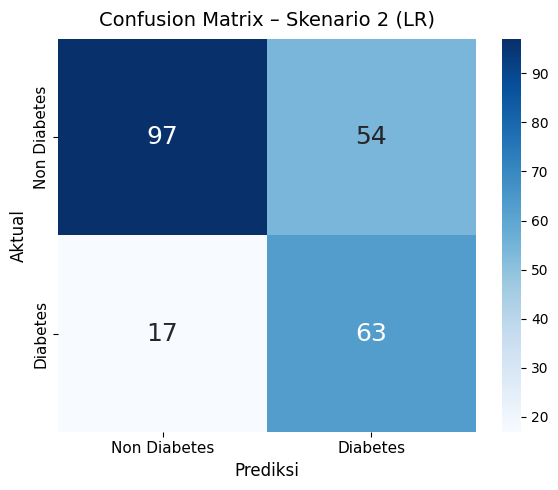

  Hasil Evaluasi Testing – Skenario 2 (LR)
  Akurasi  : 0.6926
  Presisi  : 0.5385
  Recall   : 0.7875
  F1-Score : 0.6396


In [21]:
lr_final = grid_lr.best_estimator_
import time
_t0 = time.time()
y_pred_lr_final = lr_final.predict(X_test)
waktu_predict_lr = (time.time() - _t0) * 1000  # ms
tampilkan_tabel_perbandingan(y_pred_lr_final, y_test, nama_skenario="Skenario 2")
print(f"waktu_predict_lr: {waktu_predict_lr:.2f} ms")
plot_confusion_matrix("Skenario 2 (LR)", y_test, y_pred_lr_final)
hasil_lr_final = evaluasi_testing("Skenario 2 (LR)", y_test, y_pred_lr_final)

### Skenario 3 (SVM)

In [22]:
import time
_t0 = time.time()
# membuat model SVM dengan GridSearchCV
param_grid_svm = {
    "C": [0.1, 1, 10, 100, 1000],
    "gamma": ["scale", "auto"],
    "kernel": ["rbf", "linear"],
}
grid_svm = GridSearchCV(
    SVC(random_state=42, probability=True),param_grid_svm,cv=kfold,
    scoring="accuracy",n_jobs=-1,verbose=1,
)
grid_svm.fit(X_train_smote, y_train_smote)
print(f"SVM Best Score: {grid_svm.best_score_:.4f}")
print(f"SVM Best Params: {grid_svm.best_params_}")
results_svm = pd.DataFrame(grid_svm.cv_results_)
best_idx = grid_svm.best_index_
for fold in range(kfold.get_n_splits()):
    fold_score = results_svm.loc[best_idx, f"split{fold}_test_score"]
    print(f"Fold {fold+1}: {fold_score:.4f}")
print(f"Mean: {grid_svm.best_score_:.4f}")
waktu_train_svm = (time.time() - _t0) * 1000  # ms
print(f"waktu_train_svm: {waktu_train_svm:.2f} ms")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
SVM Best Score: 0.8137
SVM Best Params: {'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}
Fold 1: 0.7714
Fold 2: 0.8071
Fold 3: 0.8714
Fold 4: 0.8201
Fold 5: 0.7986
Mean: 0.8137
waktu_train_svm: 2445.50 ms


,Prediksi Skenario 3(y_pred),Label Aktual(y_test),Keterangan
0,1,0,Tebakan Salah (False Positive)
1,0,0,Tebakan Benar (True Negative)
2,0,0,Tebakan Benar (True Negative)
3,0,0,Tebakan Benar (True Negative)
4,1,0,Tebakan Salah (False Positive)


waktu_predict_svm: 7.26 ms


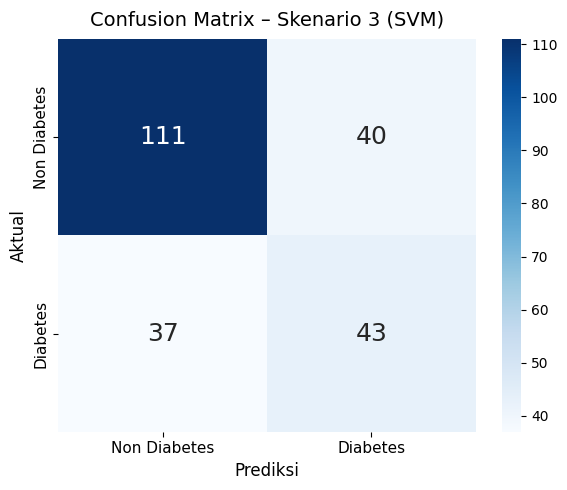

  Hasil Evaluasi Testing – Skenario 3 (SVM)
  Akurasi  : 0.6667
  Presisi  : 0.5181
  Recall   : 0.5375
  F1-Score : 0.5276


In [23]:
svm_final = grid_svm.best_estimator_
import time
_t0 = time.time()
y_pred_svm_final = svm_final.predict(X_test)
waktu_predict_svm = (time.time() - _t0) * 1000  # ms
tampilkan_tabel_perbandingan(y_pred_svm_final, y_test, nama_skenario="Skenario 3")
print(f"waktu_predict_svm: {waktu_predict_svm:.2f} ms")
plot_confusion_matrix("Skenario 3 (SVM)", y_test, y_pred_svm_final)
hasil_svm_final = evaluasi_testing("Skenario 3 (SVM)", y_test, y_pred_svm_final)

### Skenario 4 (ANN)

In [24]:
import time
_t0 = time.time()
# membuat model ann dengan GridSearchCV
param_grid_ann = {
    "max_iter": [100, 500, 1000],
    "hidden_layer_sizes": [(100,), (50, 50), (30, 20), (20, 10)],
    "activation": ["relu", "tanh", "logistic"],
    "learning_rate_init": [0.0001, 0.001],
}
grid_ann = GridSearchCV(
    MLPClassifier(random_state=42),param_grid_ann,cv=kfold,
    scoring="accuracy",n_jobs=-1,verbose=1,
)
grid_ann.fit(X_train_smote, y_train_smote)
print(f"ANN Best Score: {grid_ann.best_score_:.4f}")
print(f"ANN Best Params: {grid_ann.best_params_}")
results_ann = pd.DataFrame(grid_ann.cv_results_)
best_idx = grid_ann.best_index_
for fold in range(kfold.get_n_splits()):
    fold_score = results_ann.loc[best_idx, f"split{fold}_test_score"]
    print(f"Fold {fold+1}: {fold_score:.4f}")
print(f"Mean: {grid_ann.best_score_:.4f}")
waktu_train_ann = (time.time() - _t0) * 1000  # ms
print(f"waktu_train_ann: {waktu_train_ann:.2f} ms")

Fitting 5 folds for each of 72 candidates, totalling 360 fits
ANN Best Score: 0.8166
ANN Best Params: {'activation': 'relu', 'hidden_layer_sizes': (100,), 'learning_rate_init': 0.001, 'max_iter': 1000}
Fold 1: 0.8000
Fold 2: 0.8071
Fold 3: 0.8286
Fold 4: 0.8417
Fold 5: 0.8058
Mean: 0.8166
waktu_train_ann: 47076.97 ms


,Prediksi Skenario 4(y_pred),Label Aktual(y_test),Keterangan
0,1,0,Tebakan Salah (False Positive)
1,0,0,Tebakan Benar (True Negative)
2,0,0,Tebakan Benar (True Negative)
3,0,0,Tebakan Benar (True Negative)
4,1,0,Tebakan Salah (False Positive)


waktu_predict_ann: 2.17 ms


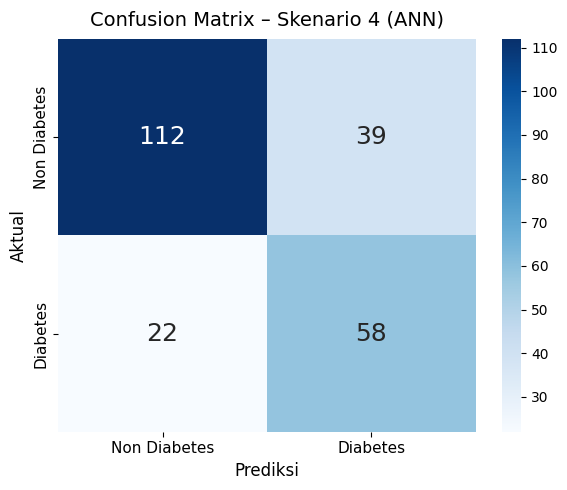

  Hasil Evaluasi Testing – Skenario 4 (ANN)
  Akurasi  : 0.7359
  Presisi  : 0.5979
  Recall   : 0.7250
  F1-Score : 0.6554


In [25]:
ann_final = grid_ann.best_estimator_
import time
_t0 = time.time()
y_pred_ann_final = ann_final.predict(X_test)
waktu_predict_ann = (time.time() - _t0) * 1000  # ms
tampilkan_tabel_perbandingan(y_pred_ann_final, y_test, nama_skenario="Skenario 4")
print(f"waktu_predict_ann: {waktu_predict_ann:.2f} ms")
plot_confusion_matrix("Skenario 4 (ANN)", y_test, y_pred_ann_final)
hasil_ann_final = evaluasi_testing("Skenario 4 (ANN)", y_test, y_pred_ann_final)

### MEMBUAT DATA TRAINING DAN TESTING UNTUK META LEARNER

In [26]:
import time
_t0_meta_train = time.time()
models = [
    ("knn", knn_final),("lr",  lr_final),
    ("svm", svm_final),("ann", ann_final),
]
dataset_training_meta = []
for train_idx, val_idx in kfold.split(X_train_smote, y_train_smote):
    X_tr  = X_train_smote.iloc[train_idx]
    y_tr  = y_train_smote.iloc[train_idx]
    X_val = X_train_smote.iloc[val_idx]
    fold_preds = []
    for name, est in models:
        model = clone(est)
        model.fit(X_tr, y_tr)
        proba = model.predict_proba(X_val)
        fold_preds.append(pd.DataFrame(
            proba,index=val_idx,columns=[f"{name}_prob_0", f"{name}_prob_1"]
        ))
    fold_df = pd.concat(fold_preds, axis=1)
    dataset_training_meta.append(fold_df)
df_fitur_meta = pd.concat(dataset_training_meta).sort_index()
waktu_buat_dataset_training_meta = (time.time() - _t0_meta_train) * 1000  # ms
print(f"waktu_buat_dataset_training_meta: {waktu_buat_dataset_training_meta:.2f} ms")

waktu_buat_dataset_training_meta: 5555.01 ms


In [27]:
# df_fitur_meta.to_excel("fitur_meta_training.xlsx", index=False)
df_fitur_meta

,knn_prob_0,knn_prob_1,lr_prob_0,lr_prob_1,svm_prob_0,svm_prob_1,ann_prob_0,ann_prob_1
0,1.000000,0.000000,0.672506,0.327494,0.908861,0.091139,0.991984,0.008016
1,0.805989,0.194011,0.449064,0.550936,0.983101,0.016899,0.971717,0.028283
2,0.328951,0.671049,0.419590,0.580410,0.380454,0.619546,0.155454,0.844546
3,0.834726,0.165274,0.499868,0.500132,0.722074,0.277926,0.553143,0.446857
4,0.588388,0.411612,0.497266,0.502734,0.128600,0.871400,0.503249,0.496751
...,...,...,...,...,...,...,...,...
693,0.000000,1.000000,0.386280,0.613720,0.133414,0.866586,0.037572,0.962428
694,0.068006,0.931994,0.485309,0.514691,0.344198,0.655802,0.425783,0.574217
695,0.210106,0.789894,0.568730,0.431270,0.231804,0.768196,0.553631,0.446369
696,0.000000,1.000000,0.461022,0.538978,0.047204,0.952796,0.096622,0.903378


In [28]:
import time
_t0_meta_test = time.time()
dataset_testing_meta = []
for name, est in models:
    proba = est.predict_proba(X_test)
    dataset_testing_meta.append(pd.DataFrame(
        proba,
        columns=[f"{name}_prob_0", f"{name}_prob_1"]
    ))
df_fitur_meta_uji = pd.concat(dataset_testing_meta, axis=1)
waktu_buat_dataset_testing_meta = (time.time() - _t0_meta_test) * 1000  # ms
print(f"waktu_buat_dataset_testing_meta: {waktu_buat_dataset_testing_meta:.2f} ms")

waktu_buat_dataset_testing_meta: 12.40 ms


In [29]:
# df_fitur_meta_uji.to_excel("fitur_meta_testing.xlsx", index=False)
df_fitur_meta_uji

,knn_prob_0,knn_prob_1,lr_prob_0,lr_prob_1,svm_prob_0,svm_prob_1,ann_prob_0,ann_prob_1
0,0.180841,0.819159,0.441192,0.558808,0.280483,0.719517,0.207317,0.792683
1,0.420075,0.579925,0.574276,0.425724,0.894007,0.105993,0.953710,0.046290
2,0.801361,0.198639,0.599517,0.400483,0.702984,0.297016,0.948309,0.051691
3,0.381380,0.618620,0.535100,0.464900,0.618300,0.381700,0.731852,0.268148
4,0.166765,0.833235,0.385449,0.614551,0.448919,0.551081,0.437892,0.562108
...,...,...,...,...,...,...,...,...
226,1.000000,0.000000,0.594996,0.405004,0.452406,0.547594,0.926129,0.073871
227,0.805178,0.194822,0.505669,0.494331,0.525083,0.474917,0.500714,0.499286
228,0.314287,0.685713,0.469929,0.530071,0.500000,0.500000,0.489024,0.510976
229,0.373472,0.626528,0.558269,0.441731,0.545867,0.454133,0.815912,0.184088


In [30]:
X_meta_latih = df_fitur_meta
y_meta_latih = y_train_smote
X_meta_uji = df_fitur_meta_uji
y_meta_uji = y_test

In [31]:
print((df_fitur_meta.index == y_train_smote.index).all()) ## ngecek apakah urutan index fitur meta latih sama dengan label latih

True


### Cek Korelasi Hasil Prediksi Base Learner

=== MATRIKS KORELASI ANTAR BASE LEARNER (OOF) [70:30] ===
        KNN      LR     SVM     ANN
KNN  1.0000  0.7739  0.8326  0.8453
LR   0.7739  1.0000  0.6911  0.8320
SVM  0.8326  0.6911  1.0000  0.8124
ANN  0.8453  0.8320  0.8124  1.0000


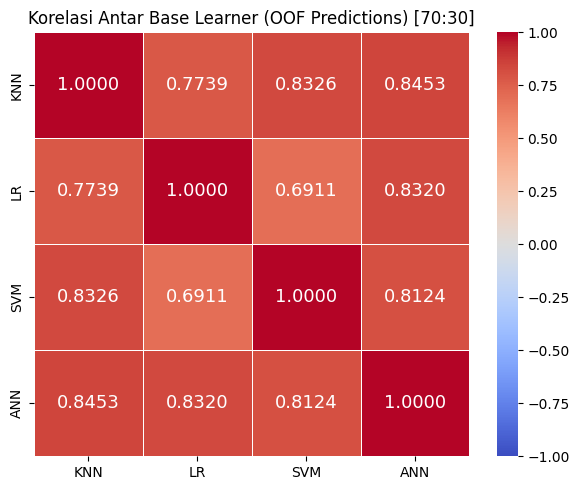


Interpretasi:
  KNN vs LR: r = 0.7739 → 🔶 SEDANG — masih ada keberagaman, namun terbatas
  KNN vs SVM: r = 0.8326 → 🔶 SEDANG — masih ada keberagaman, namun terbatas
  KNN vs ANN: r = 0.8453 → 🔶 SEDANG — masih ada keberagaman, namun terbatas
  LR vs SVM: r = 0.6911 → ✅ RENDAH — base learner cukup beragam
  LR vs ANN: r = 0.8320 → 🔶 SEDANG — masih ada keberagaman, namun terbatas
  SVM vs ANN: r = 0.8124 → 🔶 SEDANG — masih ada keberagaman, namun terbatas


In [32]:
# ============================================================
# CEK KORELASI ANTAR BASE LEARNER
# Menggunakan OOF (Out-of-Fold) predictions dari meta-training set
# Korelasi dihitung dari prob_1 (probabilitas kelas positif) tiap base learner
# Referensi: Dietterich (2000) — base learner sebaiknya tidak berkorelasi tinggi
# agar meta-learner mendapat informasi yang beragam
# ============================================================

# Ambil hanya kolom prob_1 dari masing-masing base learner (OOF)
df_oof_prob = df_fitur_meta[[
    'knn_prob_1', 'lr_prob_1', 'svm_prob_1', 'ann_prob_1'
]].copy()
df_oof_prob.columns = ['KNN', 'LR', 'SVM', 'ANN']

# Hitung matriks korelasi
corr_matrix = df_oof_prob.corr()
print(f'=== MATRIKS KORELASI ANTAR BASE LEARNER (OOF) [70:30] ===')
print(corr_matrix.round(4))

# Visualisasi heatmap
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    corr_matrix, annot=True, fmt='.4f', cmap='coolwarm',
    vmin=-1, vmax=1, ax=ax, annot_kws={'size': 13},
    linewidths=0.5
)
ax.set_title(f'Korelasi Antar Base Learner (OOF Predictions) [70:30]', fontsize=12)
plt.tight_layout()
plt.show()

# Interpretasi otomatis
print('\nInterpretasi:')
pairs = [('KNN','LR'), ('KNN','SVM'), ('KNN','ANN'),
         ('LR','SVM'),  ('LR','ANN'),  ('SVM','ANN')]
for a, b in pairs:
    r = corr_matrix.loc[a, b]
    if abs(r) >= 0.9:
        status = '⚠️  TINGGI — base learner terlalu mirip, stacking kurang optimal'
    elif abs(r) >= 0.7:
        status = '🔶 SEDANG — masih ada keberagaman, namun terbatas'
    else:
        status = '✅ RENDAH — base learner cukup beragam'
    print(f'  {a} vs {b}: r = {r:.4f} → {status}')

### Skenario 5 Stacking (Meta-KNN)

In [33]:
import time
_t0 = time.time()
# membuat model KNN Meta dengan GridSearchCV
grid_knn_meta = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=kfold,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
)
grid_knn_meta.fit(X_meta_latih, y_meta_latih)
print(f"KNN Meta Best Score: {grid_knn_meta.best_score_:.4f}")
print(f"KNN Meta Best Params: {grid_knn_meta.best_params_}")
results_knn_meta = pd.DataFrame(grid_knn_meta.cv_results_)
best_idx = grid_knn_meta.best_index_
for fold in range(kfold.get_n_splits()):
    fold_score = results_knn_meta.loc[best_idx, f"split{fold}_test_score"]
    print(f"Fold {fold+1}: {fold_score:.4f}")
print(f"Mean: {grid_knn_meta.best_score_:.4f}")
waktu_train_knn_meta = (time.time() - _t0) * 1000  # ms
print(f"waktu_train_knn_meta: {waktu_train_knn_meta:.2f} ms")

Fitting 5 folds for each of 28 candidates, totalling 140 fits
KNN Meta Best Score: 0.8425
KNN Meta Best Params: {'metric': 'euclidean', 'n_neighbors': 15, 'weights': 'uniform'}
Fold 1: 0.8000
Fold 2: 0.8214
Fold 3: 0.8643
Fold 4: 0.8849
Fold 5: 0.8417
Mean: 0.8425
waktu_train_knn_meta: 190.93 ms


,Prediksi Skenario 5 Stacking (Meta-KNN)(y_pred),Label Aktual(y_test),Keterangan
0,1,0,Tebakan Salah (False Positive)
1,0,0,Tebakan Benar (True Negative)
2,0,0,Tebakan Benar (True Negative)
3,0,0,Tebakan Benar (True Negative)
4,1,0,Tebakan Salah (False Positive)


waktu_predict_knn_meta: 3.08 ms


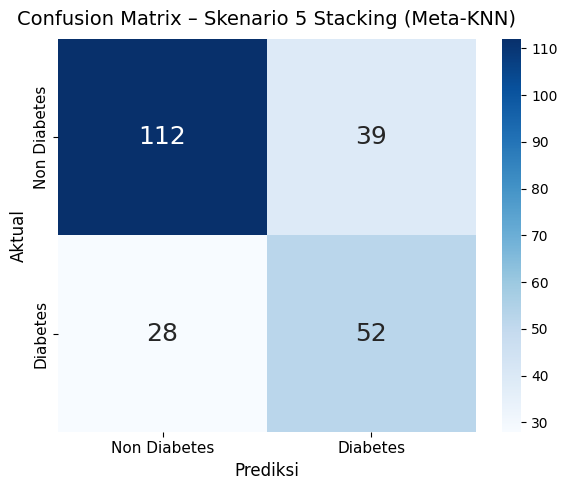

  Hasil Evaluasi Testing – Skenario 5 Stacking (Meta-KNN)
  Akurasi  : 0.7100
  Presisi  : 0.5714
  Recall   : 0.6500
  F1-Score : 0.6082


In [34]:
knn_meta_final = grid_knn_meta.best_estimator_
import time
_t0 = time.time()
y_pred_knn_meta_final = knn_meta_final.predict(X_meta_uji)
waktu_predict_knn_meta = (time.time() - _t0) * 1000  # ms
tampilkan_tabel_perbandingan(y_pred_knn_meta_final, y_test, nama_skenario="Skenario 5 Stacking (Meta-KNN)")
print(f"waktu_predict_knn_meta: {waktu_predict_knn_meta:.2f} ms")
plot_confusion_matrix("Skenario 5 Stacking (Meta-KNN)", y_test, y_pred_knn_meta_final)
hasil_knn_meta_final = evaluasi_testing("Skenario 5 Stacking (Meta-KNN)", y_test, y_pred_knn_meta_final)

### Skenario 6 Stacking (Meta-LR)

In [35]:
import time
_t0 = time.time()
# membuat model Logistic Regression Meta dengan GridSearchCV
grid_logreg_meta = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid_lr,
    cv=kfold,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
)
grid_logreg_meta.fit(X_meta_latih, y_meta_latih)
print(f"LogReg Meta Best Score: {grid_logreg_meta.best_score_:.4f}")
print(f"LogReg Meta Best Params: {grid_logreg_meta.best_params_}")
results_logreg_meta = pd.DataFrame(grid_logreg_meta.cv_results_)
best_idx = grid_logreg_meta.best_index_
for fold in range(kfold.get_n_splits()):
    fold_score = results_logreg_meta.loc[best_idx, f"split{fold}_test_score"]
    print(f"Fold {fold+1}: {fold_score:.4f}")
print(f"Mean: {grid_logreg_meta.best_score_:.4f}")
waktu_train_lr_meta = (time.time() - _t0) * 1000  # ms
print(f"waktu_train_lr_meta: {waktu_train_lr_meta:.2f} ms")

Fitting 5 folds for each of 80 candidates, totalling 400 fits
LogReg Meta Best Score: 0.8396
LogReg Meta Best Params: {'C': np.float64(0.615848211066026), 'penalty': 'l2', 'solver': 'lbfgs'}
Fold 1: 0.8143
Fold 2: 0.8143
Fold 3: 0.8643
Fold 4: 0.8777
Fold 5: 0.8273
Mean: 0.8396
waktu_train_lr_meta: 398.58 ms


,Prediksi Skenario 6 Stacking (Meta-lr)(y_pred),Label Aktual(y_test),Keterangan
0,1,0,Tebakan Salah (False Positive)
1,0,0,Tebakan Benar (True Negative)
2,0,0,Tebakan Benar (True Negative)
3,0,0,Tebakan Benar (True Negative)
4,1,0,Tebakan Salah (False Positive)


waktu_predict_lr_meta: 2.33 ms


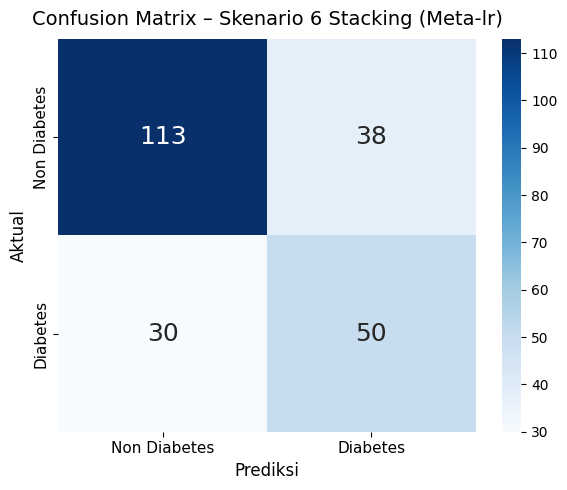

  Hasil Evaluasi Testing – Skenario 6 Stacking (Meta-lr)
  Akurasi  : 0.7056
  Presisi  : 0.5682
  Recall   : 0.6250
  F1-Score : 0.5952


In [36]:
logreg_meta_final = grid_logreg_meta.best_estimator_
import time
_t0 = time.time()
y_pred_lr_meta_final = logreg_meta_final.predict(X_meta_uji)
waktu_predict_lr_meta = (time.time() - _t0) * 1000  # ms
tampilkan_tabel_perbandingan(y_pred_lr_meta_final, y_test, nama_skenario="Skenario 6 Stacking (Meta-lr)")
print(f"waktu_predict_lr_meta: {waktu_predict_lr_meta:.2f} ms")
plot_confusion_matrix("Skenario 6 Stacking (Meta-lr)", y_test, y_pred_lr_meta_final)
hasil_lr_meta_final = evaluasi_testing("Skenario 6 Stacking (Meta-lr)", y_test, y_pred_lr_meta_final)

### Skenario 7 Stacking (Meta-SVM)

In [37]:
import time
_t0 = time.time()
# membuat model Support Vector Machine Meta dengan GridSearchCV
grid_svm_meta = GridSearchCV(
    SVC(random_state=42, probability=True),
    param_grid_svm,
    cv=kfold,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
)
grid_svm_meta.fit(X_meta_latih, y_meta_latih)
print(f"SVM Meta Best Score: {grid_svm_meta.best_score_:.4f}")
print(f"SVM Meta Best Params: {grid_svm_meta.best_params_}")
results_svm_meta = pd.DataFrame(grid_svm_meta.cv_results_)
best_idx = grid_svm_meta.best_index_
for fold in range(kfold.get_n_splits()):
    fold_score = results_svm_meta.loc[best_idx, f"split{fold}_test_score"]
    print(f"Fold {fold+1}: {fold_score:.4f}")
print(f"Mean: {grid_svm_meta.best_score_:.4f}")
waktu_train_svm_meta = (time.time() - _t0) * 1000  # ms
print(f"waktu_train_svm_meta: {waktu_train_svm_meta:.2f} ms")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
SVM Meta Best Score: 0.8381
SVM Meta Best Params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Fold 1: 0.8214
Fold 2: 0.8286
Fold 3: 0.8429
Fold 4: 0.8777
Fold 5: 0.8201
Mean: 0.8381
waktu_train_svm_meta: 1403.63 ms


,Prediksi Skenario 7 Stacking (Meta-SVM)(y_pred),Label Aktual(y_test),Keterangan
0,1,0,Tebakan Salah (False Positive)
1,0,0,Tebakan Benar (True Negative)
2,0,0,Tebakan Benar (True Negative)
3,0,0,Tebakan Benar (True Negative)
4,1,0,Tebakan Salah (False Positive)


waktu_predict_svm_meta: 4.87 ms


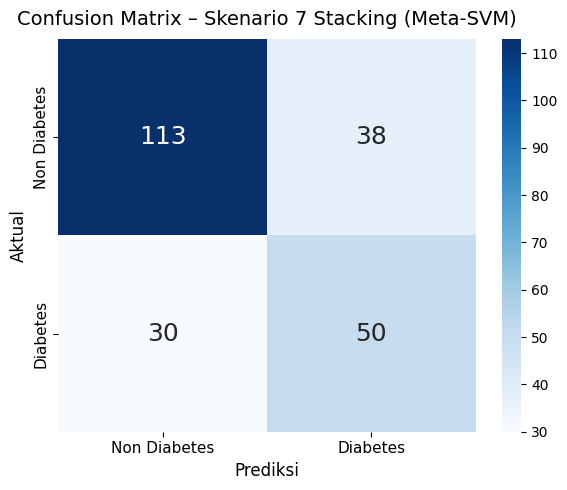

  Hasil Evaluasi Testing – Skenario 7 Stacking (Meta-SVM)
  Akurasi  : 0.7056
  Presisi  : 0.5682
  Recall   : 0.6250
  F1-Score : 0.5952


In [38]:
svm_meta_final = grid_svm_meta.best_estimator_
import time
_t0 = time.time()
y_pred_svm_meta_final = svm_meta_final.predict(X_meta_uji)
waktu_predict_svm_meta = (time.time() - _t0) * 1000  # ms
tampilkan_tabel_perbandingan(y_pred_svm_meta_final, y_test, nama_skenario="Skenario 7 Stacking (Meta-SVM)")
print(f"waktu_predict_svm_meta: {waktu_predict_svm_meta:.2f} ms")
plot_confusion_matrix("Skenario 7 Stacking (Meta-SVM)", y_test, y_pred_svm_meta_final)
hasil_svm_meta_final = evaluasi_testing("Skenario 7 Stacking (Meta-SVM)", y_test, y_pred_svm_meta_final)

### Skenario 8 Stacking (Meta-ANN)

In [39]:
import time
_t0 = time.time()
# membuat model ANN Meta dengan GridSearchCV
grid_ann_meta = GridSearchCV(
    MLPClassifier(random_state=42),
    param_grid_ann,
    cv=kfold,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
)
grid_ann_meta.fit(X_meta_latih, y_meta_latih)
print(f"ANN Meta Best Score: {grid_ann_meta.best_score_:.4f}")
print(f"ANN Meta Best Params: {grid_ann_meta.best_params_}")
results_ann_meta = pd.DataFrame(grid_ann_meta.cv_results_)
best_idx = grid_ann_meta.best_index_
for fold in range(kfold.get_n_splits()):
    fold_score = results_ann_meta.loc[best_idx, f"split{fold}_test_score"]
    print(f"Fold {fold+1}: {fold_score:.4f}")
print(f"Mean: {grid_ann_meta.best_score_:.4f}")
waktu_train_ann_meta = (time.time() - _t0) * 1000  # ms
print(f"waktu_train_ann_meta: {waktu_train_ann_meta:.2f} ms")

Fitting 5 folds for each of 72 candidates, totalling 360 fits
ANN Meta Best Score: 0.8382
ANN Meta Best Params: {'activation': 'relu', 'hidden_layer_sizes': (100,), 'learning_rate_init': 0.001, 'max_iter': 100}
Fold 1: 0.8071
Fold 2: 0.8143
Fold 3: 0.8643
Fold 4: 0.8777
Fold 5: 0.8273
Mean: 0.8382
waktu_train_ann_meta: 23511.31 ms


,Prediksi Skenario 8 Stacking (Meta-ANN)(y_pred),Label Aktual(y_test),Keterangan
0,1,0,Tebakan Salah (False Positive)
1,0,0,Tebakan Benar (True Negative)
2,0,0,Tebakan Benar (True Negative)
3,0,0,Tebakan Benar (True Negative)
4,1,0,Tebakan Salah (False Positive)


waktu_predict_ann_meta: 2.03 ms


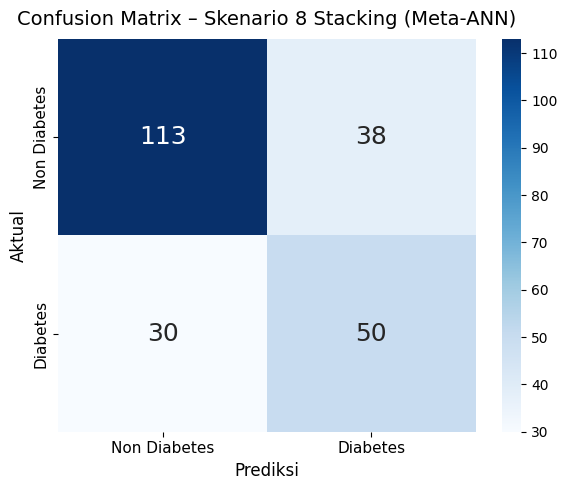

  Hasil Evaluasi Testing – Skenario 8 Stacking (Meta-ANN)
  Akurasi  : 0.7056
  Presisi  : 0.5682
  Recall   : 0.6250
  F1-Score : 0.5952


In [40]:
ann_meta_final = grid_ann_meta.best_estimator_
import time
_t0 = time.time()
y_pred_ann_meta_final = ann_meta_final.predict(X_meta_uji)
waktu_predict_ann_meta = (time.time() - _t0) * 1000  # ms
tampilkan_tabel_perbandingan(y_pred_ann_meta_final, y_test, nama_skenario="Skenario 8 Stacking (Meta-ANN)")
print(f"waktu_predict_ann_meta: {waktu_predict_ann_meta:.2f} ms")
plot_confusion_matrix("Skenario 8 Stacking (Meta-ANN)", y_test, y_pred_ann_meta_final)
hasil_ann_meta_final = evaluasi_testing("Skenario 8 Stacking (Meta-ANN)", y_test, y_pred_ann_meta_final)

In [41]:
# === TABEL PERBANDINGAN SKENARIO 1-8 (SECTION A: 70:30) ===
hasil_semua_A = [
    hasil_knn_final,
    hasil_lr_final,
    hasil_svm_final,
    hasil_ann_final,
    hasil_knn_meta_final,
    hasil_lr_meta_final,
    hasil_svm_meta_final,
    hasil_ann_meta_final,
]

df_perbandingan_A = pd.DataFrame(hasil_semua_A)
df_perbandingan_A.insert(0, 'Pembagian Data', '70:30')
df_perbandingan_A.index = range(1, len(df_perbandingan_A) + 1)
df_perbandingan_A.index.name = 'No'
print('=== SECTION A (70:30) ===')
display(df_perbandingan_A)
print('\nModel Terbaik per Metrik (70:30):')
for metrik in ['Akurasi', 'Presisi', 'Recall', 'F1-Score']:
    best_idx = df_perbandingan_A[metrik].idxmax()
    best_model = df_perbandingan_A.loc[best_idx, 'Model']
    best_val   = df_perbandingan_A.loc[best_idx, metrik]
    print(f'  {metrik:10s}: {best_model} ({best_val:.4f})')

=== SECTION A (70:30) ===


,Pembagian Data,Model,Akurasi,Presisi,Recall,F1-Score
No,,,,,,
1,70:30,Skenario 1 (KNN),0.6537,0.5000,0.6750,0.5745
2,70:30,Skenario 2 (LR),0.6926,0.5385,0.7875,0.6396
3,70:30,Skenario 3 (SVM),0.6667,0.5181,0.5375,0.5276
4,70:30,Skenario 4 (ANN),0.7359,0.5979,0.7250,0.6554
5,70:30,Skenario 5 Stacking (Meta-KNN),0.7100,0.5714,0.6500,0.6082
6,70:30,Skenario 6 Stacking (Meta-lr),0.7056,0.5682,0.6250,0.5952
7,70:30,Skenario 7 Stacking (Meta-SVM),0.7056,0.5682,0.6250,0.5952
8,70:30,Skenario 8 Stacking (Meta-ANN),0.7056,0.5682,0.6250,0.5952



Model Terbaik per Metrik (70:30):
  Akurasi   : Skenario 4 (ANN) (0.7359)
  Presisi   : Skenario 4 (ANN) (0.5979)
  Recall    : Skenario 2 (LR) (0.7875)
  F1-Score  : Skenario 4 (ANN) (0.6554)


---
# 🟠 SECTION B — PEMBAGIAN DATA 80:20

Seluruh skenario 1–8 diulang menggunakan rasio split **80:20** (test_size=0.2).
Preprocessing (duplikat, imputasi, outlier, normalisasi) tetap sama — hanya split data yang berbeda.

In [42]:
# ============================================================
# SECTION B: SPLIT DATA 80:20
# ============================================================
X_train_B, X_test_B, y_train_B, y_test_B = train_test_split(
    X_ternormalisasi, y, test_size=0.2, random_state=42
)
print(f'[80:20] Jumlah data train : {len(X_train_B)}')
print(f'[80:20] Jumlah data test  : {len(X_test_B)}')

[80:20] Jumlah data train : 614
[80:20] Jumlah data test  : 154


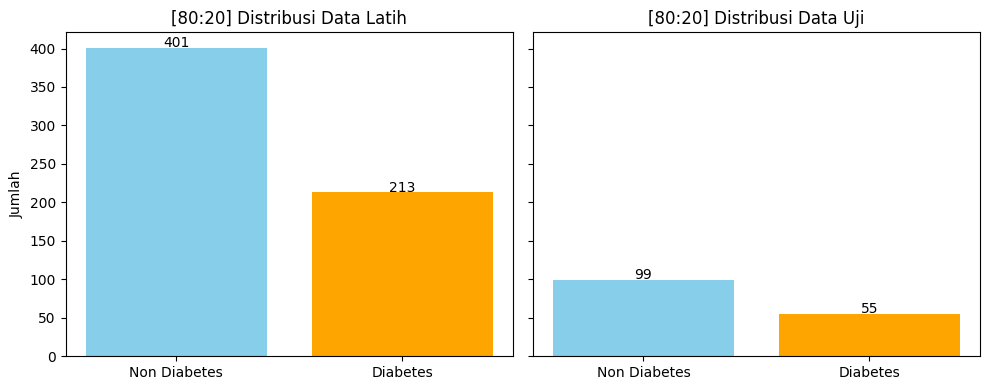

In [43]:
train_y_counts_B = y_train_B.value_counts()
test_counts_B = y_test_B.value_counts().reindex([0, 1], fill_value=0)

labels = ['Non Diabetes', 'Diabetes']
x = [0, 1]
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
axes[0].bar(x, train_y_counts_B.values, color=['skyblue', 'orange'])
axes[0].set_title('[80:20] Distribusi Data Latih')
axes[0].set_xticks(x); axes[0].set_xticklabels(labels); axes[0].set_ylabel('Jumlah')
axes[1].bar(x, test_counts_B.values, color=['skyblue', 'orange'])
axes[1].set_title('[80:20] Distribusi Data Uji')
axes[1].set_xticks(x); axes[1].set_xticklabels(labels)
for ax, counts in zip(axes, [train_y_counts_B, test_counts_B]):
    for i, v in enumerate(counts.values):
        ax.text(i, v + 1, str(int(v)), ha='center')
plt.tight_layout(); plt.show()

### Balancing Data (80:20)

[80:20] Imbalance Ratio: 1.8826291079812207


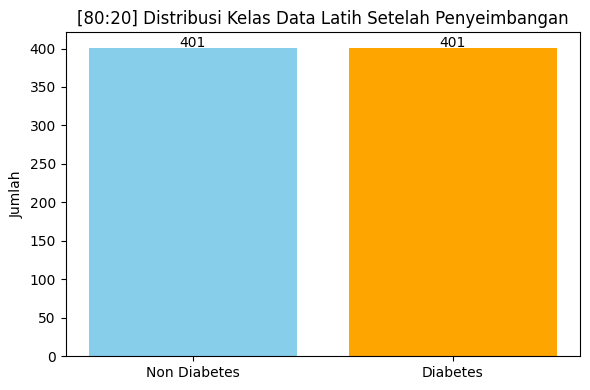

In [44]:
jumlah_per_kelas_B = y_train_B.value_counts()
IR_B = jumlah_per_kelas_B.max() / jumlah_per_kelas_B.min()
print(f'[80:20] Imbalance Ratio: {IR_B}')
if IR_B > 1.5:
    smote_B = SMOTE(random_state=42)
    X_train_smote_B, y_train_smote_B = smote_B.fit_resample(X_train_B, y_train_B)
else:
    X_train_smote_B, y_train_smote_B = X_train_B.copy(), y_train_B.copy()
    print('Data sudah cukup seimbang')

counts_smote_B = y_train_smote_B.value_counts()
plt.figure(figsize=(6, 4))
plt.bar([0, 1], counts_smote_B.values, color=['skyblue', 'orange'])
plt.xticks([0, 1], ['Non Diabetes', 'Diabetes'])
plt.ylabel('Jumlah')
plt.title('[80:20] Distribusi Kelas Data Latih Setelah Penyeimbangan')
for i, v in enumerate(counts_smote_B.values):
    plt.text(i, v + 1, str(int(v)), ha='center')
plt.tight_layout(); plt.show()

## UJI COBA SKENARIO (80:20)

In [45]:
kfold_B = KFold(n_splits=5, shuffle=True, random_state=42)

### Skenario 1 (KNN) [80:20]

In [46]:
import time
_t0 = time.time()
grid_knn_B = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=kfold_B, scoring='accuracy', n_jobs=-1, verbose=1,
)
grid_knn_B.fit(X_train_smote_B, y_train_smote_B)
print(f'KNN Best Score (80:20): {grid_knn_B.best_score_:.4f}')
print(f'KNN Best Params: {grid_knn_B.best_params_}')
results_knn_B = pd.DataFrame(grid_knn_B.cv_results_)
best_idx = grid_knn_B.best_index_
for fold in range(kfold_B.get_n_splits()):
    fold_score = results_knn_B.loc[best_idx, f'split{fold}_test_score']
    print(f'Fold {fold+1}: {fold_score:.4f}')
print(f'Mean: {grid_knn_B.best_score_:.4f}')
waktu_train_knn_B = (time.time() - _t0) * 1000
print(f'waktu_train_knn_B: {waktu_train_knn_B:.2f} ms')

Fitting 5 folds for each of 28 candidates, totalling 140 fits
KNN Best Score (80:20): 0.8092
KNN Best Params: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'}
Fold 1: 0.8137
Fold 2: 0.8261
Fold 3: 0.8000
Fold 4: 0.8250
Fold 5: 0.7812
Mean: 0.8092
waktu_train_knn_B: 218.61 ms


,Prediksi Skenario 1 [80:20](y_pred),Label Aktual(y_test),Keterangan
0,1,0,Tebakan Salah (False Positive)
1,0,0,Tebakan Benar (True Negative)
2,0,0,Tebakan Benar (True Negative)
3,0,0,Tebakan Benar (True Negative)
4,1,0,Tebakan Salah (False Positive)


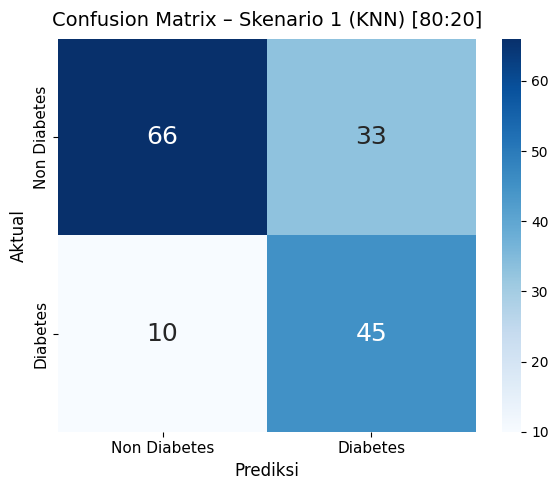

  Hasil Evaluasi Testing – Skenario 1 (KNN) [80:20]
  Akurasi  : 0.7208
  Presisi  : 0.5769
  Recall   : 0.8182
  F1-Score : 0.6767
waktu_predict_knn_B: 3.71 ms


In [47]:
knn_final_B = grid_knn_B.best_estimator_
import time
_t0 = time.time()
y_pred_knn_B = knn_final_B.predict(X_test_B)
waktu_predict_knn_B = (time.time() - _t0) * 1000
tampilkan_tabel_perbandingan(y_pred_knn_B, y_test_B, nama_skenario='Skenario 1 [80:20]')
plot_confusion_matrix('Skenario 1 (KNN) [80:20]', y_test_B, y_pred_knn_B)
hasil_knn_B = evaluasi_testing('Skenario 1 (KNN) [80:20]', y_test_B, y_pred_knn_B)
print(f'waktu_predict_knn_B: {waktu_predict_knn_B:.2f} ms')

### Skenario 2 (LR) [80:20]

In [48]:
import time
_t0 = time.time()
grid_lr_B = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid_lr,
    cv=kfold_B, scoring='accuracy', n_jobs=-1, verbose=1,
)
grid_lr_B.fit(X_train_smote_B, y_train_smote_B)
print(f'LR Best Score (80:20): {grid_lr_B.best_score_:.4f}')
print(f'LR Best Params: {grid_lr_B.best_params_}')
results_lr_B = pd.DataFrame(grid_lr_B.cv_results_)
best_idx = grid_lr_B.best_index_
for fold in range(kfold_B.get_n_splits()):
    fold_score = results_lr_B.loc[best_idx, f'split{fold}_test_score']
    print(f'Fold {fold+1}: {fold_score:.4f}')
print(f'Mean: {grid_lr_B.best_score_:.4f}')
waktu_train_lr_B = (time.time() - _t0) * 1000
print(f'waktu_train_lr_B: {waktu_train_lr_B:.2f} ms')

Fitting 5 folds for each of 80 candidates, totalling 400 fits
LR Best Score (80:20): 0.7643
LR Best Params: {'C': np.float64(1.623776739188721), 'penalty': 'l1', 'solver': 'liblinear'}
Fold 1: 0.7826
Fold 2: 0.7453
Fold 3: 0.8125
Fold 4: 0.7188
Fold 5: 0.7625
Mean: 0.7643
waktu_train_lr_B: 439.55 ms


,Prediksi Skenario 2 [80:20](y_pred),Label Aktual(y_test),Keterangan
0,0,0,Tebakan Benar (True Negative)
1,0,0,Tebakan Benar (True Negative)
2,0,0,Tebakan Benar (True Negative)
3,0,0,Tebakan Benar (True Negative)
4,1,0,Tebakan Salah (False Positive)


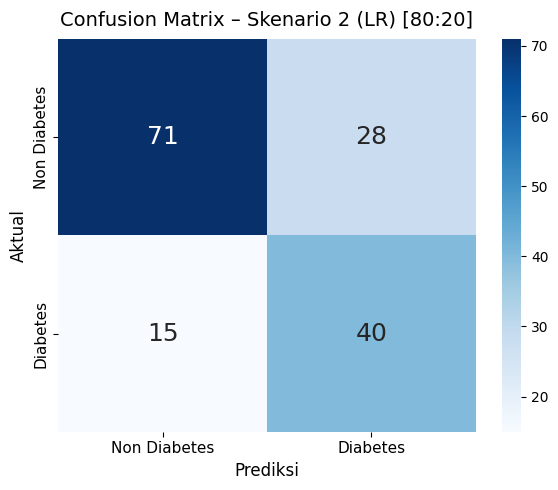

  Hasil Evaluasi Testing – Skenario 2 (LR) [80:20]
  Akurasi  : 0.7208
  Presisi  : 0.5882
  Recall   : 0.7273
  F1-Score : 0.6504
waktu_predict_lr_B: 1.15 ms


In [49]:
lr_final_B = grid_lr_B.best_estimator_
import time
_t0 = time.time()
y_pred_lr_B = lr_final_B.predict(X_test_B)
waktu_predict_lr_B = (time.time() - _t0) * 1000
tampilkan_tabel_perbandingan(y_pred_lr_B, y_test_B, nama_skenario='Skenario 2 [80:20]')
plot_confusion_matrix('Skenario 2 (LR) [80:20]', y_test_B, y_pred_lr_B)
hasil_lr_B = evaluasi_testing('Skenario 2 (LR) [80:20]', y_test_B, y_pred_lr_B)
print(f'waktu_predict_lr_B: {waktu_predict_lr_B:.2f} ms')

### Skenario 3 (SVM) [80:20]

In [50]:
import time
_t0 = time.time()
grid_svm_B = GridSearchCV(
    SVC(random_state=42, probability=True),
    param_grid_svm,
    cv=kfold_B, scoring='accuracy', n_jobs=-1, verbose=1,
)
grid_svm_B.fit(X_train_smote_B, y_train_smote_B)
print(f'SVM Best Score (80:20): {grid_svm_B.best_score_:.4f}')
print(f'SVM Best Params: {grid_svm_B.best_params_}')
results_svm_B = pd.DataFrame(grid_svm_B.cv_results_)
best_idx = grid_svm_B.best_index_
for fold in range(kfold_B.get_n_splits()):
    fold_score = results_svm_B.loc[best_idx, f'split{fold}_test_score']
    print(f'Fold {fold+1}: {fold_score:.4f}')
print(f'Mean: {grid_svm_B.best_score_:.4f}')
waktu_train_svm_B = (time.time() - _t0) * 1000
print(f'waktu_train_svm_B: {waktu_train_svm_B:.2f} ms')

Fitting 5 folds for each of 20 candidates, totalling 100 fits
SVM Best Score (80:20): 0.7968
SVM Best Params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Fold 1: 0.7950
Fold 2: 0.7453
Fold 3: 0.8438
Fold 4: 0.8063
Fold 5: 0.7937
Mean: 0.7968
waktu_train_svm_B: 2480.99 ms


,Prediksi Skenario 3 [80:20](y_pred),Label Aktual(y_test),Keterangan
0,1,0,Tebakan Salah (False Positive)
1,0,0,Tebakan Benar (True Negative)
2,0,0,Tebakan Benar (True Negative)
3,0,0,Tebakan Benar (True Negative)
4,1,0,Tebakan Salah (False Positive)


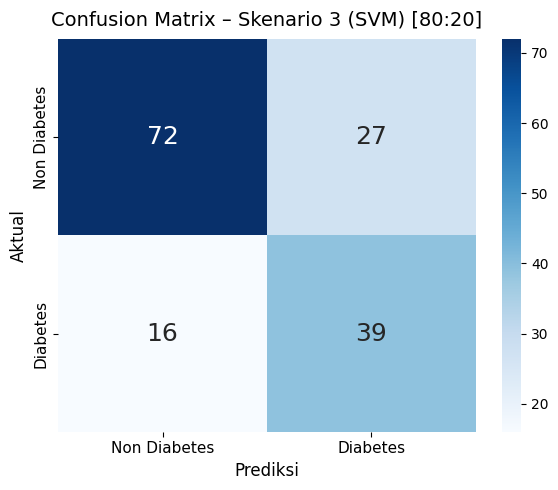

  Hasil Evaluasi Testing – Skenario 3 (SVM) [80:20]
  Akurasi  : 0.7208
  Presisi  : 0.5909
  Recall   : 0.7091
  F1-Score : 0.6446
waktu_predict_svm_B: 6.53 ms


In [51]:
svm_final_B = grid_svm_B.best_estimator_
import time
_t0 = time.time()
y_pred_svm_B = svm_final_B.predict(X_test_B)
waktu_predict_svm_B = (time.time() - _t0) * 1000
tampilkan_tabel_perbandingan(y_pred_svm_B, y_test_B, nama_skenario='Skenario 3 [80:20]')
plot_confusion_matrix('Skenario 3 (SVM) [80:20]', y_test_B, y_pred_svm_B)
hasil_svm_B = evaluasi_testing('Skenario 3 (SVM) [80:20]', y_test_B, y_pred_svm_B)
print(f'waktu_predict_svm_B: {waktu_predict_svm_B:.2f} ms')

### Skenario 4 (ANN) [80:20]

In [52]:
import time
_t0 = time.time()
grid_ann_B = GridSearchCV(
    MLPClassifier(random_state=42),
    param_grid_ann,
    cv=kfold_B, scoring='accuracy', n_jobs=-1, verbose=1,
)
grid_ann_B.fit(X_train_smote_B, y_train_smote_B)
print(f'ANN Best Score (80:20): {grid_ann_B.best_score_:.4f}')
print(f'ANN Best Params: {grid_ann_B.best_params_}')
results_ann_B = pd.DataFrame(grid_ann_B.cv_results_)
best_idx = grid_ann_B.best_index_
for fold in range(kfold_B.get_n_splits()):
    fold_score = results_ann_B.loc[best_idx, f'split{fold}_test_score']
    print(f'Fold {fold+1}: {fold_score:.4f}')
print(f'Mean: {grid_ann_B.best_score_:.4f}')
waktu_train_ann_B = (time.time() - _t0) * 1000
print(f'waktu_train_ann_B: {waktu_train_ann_B:.2f} ms')

Fitting 5 folds for each of 72 candidates, totalling 360 fits
ANN Best Score (80:20): 0.8043
ANN Best Params: {'activation': 'relu', 'hidden_layer_sizes': (100,), 'learning_rate_init': 0.001, 'max_iter': 1000}
Fold 1: 0.8199
Fold 2: 0.7702
Fold 3: 0.8438
Fold 4: 0.7937
Fold 5: 0.7937
Mean: 0.8043
waktu_train_ann_B: 47066.89 ms


,Prediksi Skenario 4 [80:20](y_pred),Label Aktual(y_test),Keterangan
0,1,0,Tebakan Salah (False Positive)
1,0,0,Tebakan Benar (True Negative)
2,0,0,Tebakan Benar (True Negative)
3,0,0,Tebakan Benar (True Negative)
4,1,0,Tebakan Salah (False Positive)


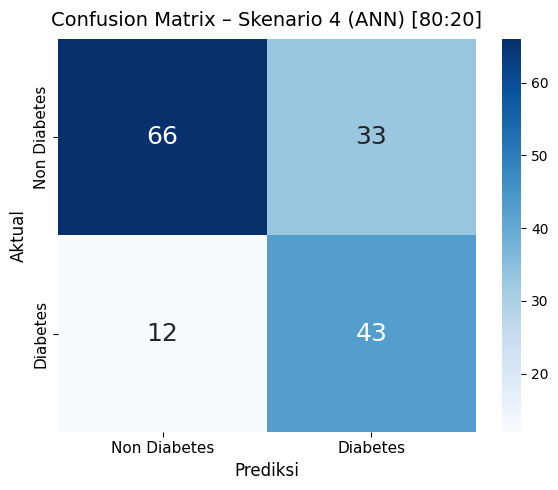

  Hasil Evaluasi Testing – Skenario 4 (ANN) [80:20]
  Akurasi  : 0.7078
  Presisi  : 0.5658
  Recall   : 0.7818
  F1-Score : 0.6565
waktu_predict_ann_B: 0.99 ms


In [53]:
ann_final_B = grid_ann_B.best_estimator_
import time
_t0 = time.time()
y_pred_ann_B = ann_final_B.predict(X_test_B)
waktu_predict_ann_B = (time.time() - _t0) * 1000
tampilkan_tabel_perbandingan(y_pred_ann_B, y_test_B, nama_skenario='Skenario 4 [80:20]')
plot_confusion_matrix('Skenario 4 (ANN) [80:20]', y_test_B, y_pred_ann_B)
hasil_ann_B = evaluasi_testing('Skenario 4 (ANN) [80:20]', y_test_B, y_pred_ann_B)
print(f'waktu_predict_ann_B: {waktu_predict_ann_B:.2f} ms')

### MEMBUAT DATA TRAINING DAN TESTING UNTUK META LEARNER [80:20]

In [54]:
import time
_t0_meta_train_B = time.time()
models_B = [
    ('knn', knn_final_B), ('lr', lr_final_B),
    ('svm', svm_final_B), ('ann', ann_final_B),
]
dataset_training_meta_B = []
for train_idx, val_idx in kfold_B.split(X_train_smote_B, y_train_smote_B):
    X_tr  = X_train_smote_B.iloc[train_idx]
    y_tr  = y_train_smote_B.iloc[train_idx]
    X_val = X_train_smote_B.iloc[val_idx]
    fold_preds = []
    for name, est in models_B:
        model = clone(est)
        model.fit(X_tr, y_tr)
        proba = model.predict_proba(X_val)
        fold_preds.append(pd.DataFrame(
            proba, index=val_idx, columns=[f'{name}_prob_0', f'{name}_prob_1']
        ))
    fold_df = pd.concat(fold_preds, axis=1)
    dataset_training_meta_B.append(fold_df)
df_fitur_meta_B = pd.concat(dataset_training_meta_B).sort_index()
waktu_buat_dataset_training_meta_B = (time.time() - _t0_meta_train_B) * 1000
print(f'waktu_buat_dataset_training_meta_B: {waktu_buat_dataset_training_meta_B:.2f} ms')
df_fitur_meta_B

waktu_buat_dataset_training_meta_B: 4837.61 ms


,knn_prob_0,knn_prob_1,lr_prob_0,lr_prob_1,svm_prob_0,svm_prob_1,ann_prob_0,ann_prob_1
0,1.000000,0.000000,0.913657,0.086343,0.956505,0.043495,0.986265,0.013735
1,0.510445,0.489555,0.505194,0.494806,0.481752,0.518248,0.686079,0.313921
2,1.000000,0.000000,0.576948,0.423052,0.760500,0.239500,0.578370,0.421630
3,0.380204,0.619796,0.235127,0.764873,0.733424,0.266576,0.519507,0.480493
4,0.423471,0.576529,0.134509,0.865491,0.574301,0.425699,0.078212,0.921788
...,...,...,...,...,...,...,...,...
797,0.000000,1.000000,0.465812,0.534188,0.305140,0.694860,0.415855,0.584145
798,0.022982,0.977018,0.132428,0.867572,0.198680,0.801320,0.050830,0.949170
799,0.178005,0.821995,0.458663,0.541337,0.175161,0.824839,0.370419,0.629581
800,0.096244,0.903756,0.269315,0.730685,0.202569,0.797431,0.141426,0.858574


In [55]:
import time
_t0_meta_test_B = time.time()
dataset_testing_meta_B = []
for name, est in models_B:
    proba = est.predict_proba(X_test_B)
    dataset_testing_meta_B.append(pd.DataFrame(
        proba, columns=[f'{name}_prob_0', f'{name}_prob_1']
    ))
df_fitur_meta_uji_B = pd.concat(dataset_testing_meta_B, axis=1)
waktu_buat_dataset_testing_meta_B = (time.time() - _t0_meta_test_B) * 1000
print(f'waktu_buat_dataset_testing_meta_B: {waktu_buat_dataset_testing_meta_B:.2f} ms')
df_fitur_meta_uji_B

waktu_buat_dataset_testing_meta_B: 10.58 ms


,knn_prob_0,knn_prob_1,lr_prob_0,lr_prob_1,svm_prob_0,svm_prob_1,ann_prob_0,ann_prob_1
0,0.409527,0.590473,0.561155,0.438845,0.136011,0.863989,0.335745,0.664255
1,0.587718,0.412282,0.751468,0.248532,0.935115,0.064885,0.752032,0.247968
2,0.803178,0.196822,0.823990,0.176010,0.791929,0.208071,0.793128,0.206872
3,0.592200,0.407800,0.747037,0.252963,0.653110,0.346890,0.594968,0.405032
4,0.190647,0.809353,0.384325,0.615675,0.439664,0.560336,0.371927,0.628073
...,...,...,...,...,...,...,...,...
149,0.187841,0.812159,0.142067,0.857933,0.289631,0.710369,0.187529,0.812471
150,0.824506,0.175494,0.813071,0.186929,0.894201,0.105799,0.732572,0.267428
151,0.630360,0.369640,0.398919,0.601081,0.444017,0.555983,0.316602,0.683398
152,0.179735,0.820265,0.500165,0.499835,0.638656,0.361344,0.404255,0.595745


In [56]:
X_meta_latih_B = df_fitur_meta_B
y_meta_latih_B = y_train_smote_B
X_meta_uji_B   = df_fitur_meta_uji_B
y_meta_uji_B   = y_test_B
print((df_fitur_meta_B.index == y_train_smote_B.index).all())

True


### Cek Korelasi Base Learner

=== MATRIKS KORELASI ANTAR BASE LEARNER (OOF) [80:20] ===
        KNN      LR     SVM     ANN
KNN  1.0000  0.7593  0.8685  0.8256
LR   0.7593  1.0000  0.8076  0.9068
SVM  0.8685  0.8076  1.0000  0.9187
ANN  0.8256  0.9068  0.9187  1.0000


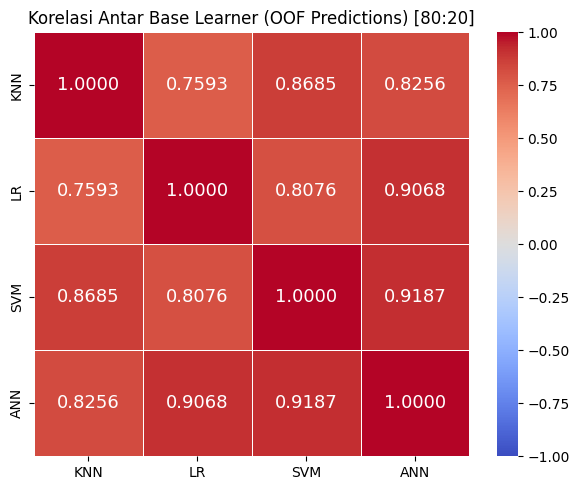


Interpretasi:
  KNN vs LR: r = 0.7593 → 🔶 SEDANG — masih ada keberagaman, namun terbatas
  KNN vs SVM: r = 0.8685 → 🔶 SEDANG — masih ada keberagaman, namun terbatas
  KNN vs ANN: r = 0.8256 → 🔶 SEDANG — masih ada keberagaman, namun terbatas
  LR vs SVM: r = 0.8076 → 🔶 SEDANG — masih ada keberagaman, namun terbatas
  LR vs ANN: r = 0.9068 → ⚠️  TINGGI — base learner terlalu mirip, stacking kurang optimal
  SVM vs ANN: r = 0.9187 → ⚠️  TINGGI — base learner terlalu mirip, stacking kurang optimal


In [57]:
# ============================================================
# CEK KORELASI ANTAR BASE LEARNER
# Menggunakan OOF (Out-of-Fold) predictions dari meta-training set
# Korelasi dihitung dari prob_1 (probabilitas kelas positif) tiap base learner
# Referensi: Dietterich (2000) — base learner sebaiknya tidak berkorelasi tinggi
# agar meta-learner mendapat informasi yang beragam
# ============================================================

# Ambil hanya kolom prob_1 dari masing-masing base learner (OOF)
df_oof_prob_B = df_fitur_meta_B[[
    'knn_prob_1', 'lr_prob_1', 'svm_prob_1', 'ann_prob_1'
]].copy()
df_oof_prob_B.columns = ['KNN', 'LR', 'SVM', 'ANN']

# Hitung matriks korelasi
corr_matrix_B = df_oof_prob_B.corr()
print(f'=== MATRIKS KORELASI ANTAR BASE LEARNER (OOF) [80:20] ===')
print(corr_matrix_B.round(4))

# Visualisasi heatmap
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    corr_matrix_B, annot=True, fmt='.4f', cmap='coolwarm',
    vmin=-1, vmax=1, ax=ax, annot_kws={'size': 13},
    linewidths=0.5
)
ax.set_title(f'Korelasi Antar Base Learner (OOF Predictions) [80:20]', fontsize=12)
plt.tight_layout()
plt.show()

# Interpretasi otomatis
print('\nInterpretasi:')
pairs = [('KNN','LR'), ('KNN','SVM'), ('KNN','ANN'),
         ('LR','SVM'),  ('LR','ANN'),  ('SVM','ANN')]
for a, b in pairs:
    r = corr_matrix_B.loc[a, b]
    if abs(r) >= 0.9:
        status = '⚠️  TINGGI — base learner terlalu mirip, stacking kurang optimal'
    elif abs(r) >= 0.7:
        status = '🔶 SEDANG — masih ada keberagaman, namun terbatas'
    else:
        status = '✅ RENDAH — base learner cukup beragam'
    print(f'  {a} vs {b}: r = {r:.4f} → {status}')

### Skenario 5 Stacking (Meta-KNN) [80:20]

In [58]:
import time
_t0 = time.time()
grid_knn_meta_B = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=kfold_B, scoring='accuracy', n_jobs=-1, verbose=1,
)
grid_knn_meta_B.fit(X_meta_latih_B, y_meta_latih_B)
print(f'KNN Meta Best Score (80:20): {grid_knn_meta_B.best_score_:.4f}')
print(f'KNN Meta Best Params: {grid_knn_meta_B.best_params_}')
results_knn_meta_B = pd.DataFrame(grid_knn_meta_B.cv_results_)
best_idx = grid_knn_meta_B.best_index_
for fold in range(kfold_B.get_n_splits()):
    fold_score = results_knn_meta_B.loc[best_idx, f'split{fold}_test_score']
    print(f'Fold {fold+1}: {fold_score:.4f}')
print(f'Mean: {grid_knn_meta_B.best_score_:.4f}')
waktu_train_knn_meta_B = (time.time() - _t0) * 1000
print(f'waktu_train_knn_meta_B: {waktu_train_knn_meta_B:.2f} ms')

Fitting 5 folds for each of 28 candidates, totalling 140 fits
KNN Meta Best Score (80:20): 0.8179
KNN Meta Best Params: {'metric': 'manhattan', 'n_neighbors': 13, 'weights': 'uniform'}
Fold 1: 0.8385
Fold 2: 0.8199
Fold 3: 0.8313
Fold 4: 0.8250
Fold 5: 0.7750
Mean: 0.8179
waktu_train_knn_meta_B: 185.63 ms


,Prediksi Skenario 5 [80:20](y_pred),Label Aktual(y_test),Keterangan
0,1,0,Tebakan Salah (False Positive)
1,0,0,Tebakan Benar (True Negative)
2,0,0,Tebakan Benar (True Negative)
3,0,0,Tebakan Benar (True Negative)
4,0,0,Tebakan Benar (True Negative)


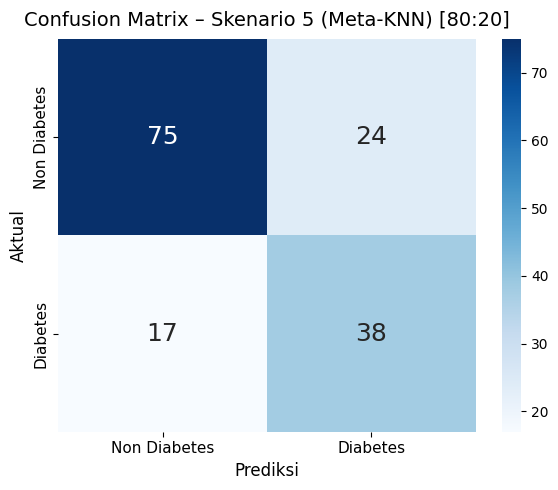

  Hasil Evaluasi Testing – Skenario 5 (Meta-KNN) [80:20]
  Akurasi  : 0.7338
  Presisi  : 0.6129
  Recall   : 0.6909
  F1-Score : 0.6496
waktu_predict_knn_meta_B: 5.36 ms


In [59]:
knn_meta_final_B = grid_knn_meta_B.best_estimator_
import time
_t0 = time.time()
y_pred_knn_meta_B = knn_meta_final_B.predict(X_meta_uji_B)
waktu_predict_knn_meta_B = (time.time() - _t0) * 1000
tampilkan_tabel_perbandingan(y_pred_knn_meta_B, y_test_B, nama_skenario='Skenario 5 [80:20]')
plot_confusion_matrix('Skenario 5 (Meta-KNN) [80:20]', y_test_B, y_pred_knn_meta_B)
hasil_knn_meta_B = evaluasi_testing('Skenario 5 (Meta-KNN) [80:20]', y_test_B, y_pred_knn_meta_B)
print(f'waktu_predict_knn_meta_B: {waktu_predict_knn_meta_B:.2f} ms')

### Skenario 6 Stacking (Meta-LR) [80:20]

In [60]:
import time
_t0 = time.time()
grid_logreg_meta_B = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid_lr,
    cv=kfold_B, scoring='accuracy', n_jobs=-1, verbose=1,
)
grid_logreg_meta_B.fit(X_meta_latih_B, y_meta_latih_B)
print(f'LR Meta Best Score (80:20): {grid_logreg_meta_B.best_score_:.4f}')
print(f'LR Meta Best Params: {grid_logreg_meta_B.best_params_}')
results_logreg_meta_B = pd.DataFrame(grid_logreg_meta_B.cv_results_)
best_idx = grid_logreg_meta_B.best_index_
for fold in range(kfold_B.get_n_splits()):
    fold_score = results_logreg_meta_B.loc[best_idx, f'split{fold}_test_score']
    print(f'Fold {fold+1}: {fold_score:.4f}')
print(f'Mean: {grid_logreg_meta_B.best_score_:.4f}')
waktu_train_logreg_meta_B = (time.time() - _t0) * 1000
print(f'waktu_train_logreg_meta_B: {waktu_train_logreg_meta_B:.2f} ms')

Fitting 5 folds for each of 80 candidates, totalling 400 fits
LR Meta Best Score (80:20): 0.8167
LR Meta Best Params: {'C': np.float64(0.615848211066026), 'penalty': 'l2', 'solver': 'liblinear'}
Fold 1: 0.8323
Fold 2: 0.7888
Fold 3: 0.8500
Fold 4: 0.8187
Fold 5: 0.7937
Mean: 0.8167
waktu_train_logreg_meta_B: 387.36 ms


,Prediksi Skenario 6 [80:20](y_pred),Label Aktual(y_test),Keterangan
0,1,0,Tebakan Salah (False Positive)
1,0,0,Tebakan Benar (True Negative)
2,0,0,Tebakan Benar (True Negative)
3,0,0,Tebakan Benar (True Negative)
4,1,0,Tebakan Salah (False Positive)


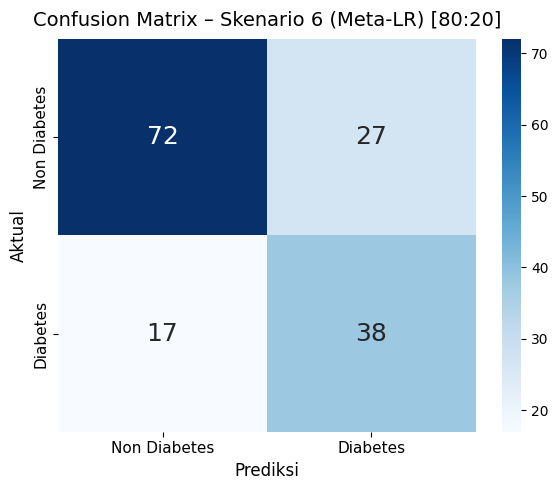

  Hasil Evaluasi Testing – Skenario 6 (Meta-LR) [80:20]
  Akurasi  : 0.7143
  Presisi  : 0.5846
  Recall   : 0.6909
  F1-Score : 0.6333
waktu_predict_lr_meta_B: 1.35 ms


In [61]:
logreg_meta_final_B = grid_logreg_meta_B.best_estimator_
import time
_t0 = time.time()
y_pred_lr_meta_B = logreg_meta_final_B.predict(X_meta_uji_B)
waktu_predict_lr_meta_B = (time.time() - _t0) * 1000
tampilkan_tabel_perbandingan(y_pred_lr_meta_B, y_test_B, nama_skenario='Skenario 6 [80:20]')
plot_confusion_matrix('Skenario 6 (Meta-LR) [80:20]', y_test_B, y_pred_lr_meta_B)
hasil_lr_meta_B = evaluasi_testing('Skenario 6 (Meta-LR) [80:20]', y_test_B, y_pred_lr_meta_B)
print(f'waktu_predict_lr_meta_B: {waktu_predict_lr_meta_B:.2f} ms')

### Skenario 7 Stacking (Meta-SVM) [80:20]

In [62]:
import time
_t0 = time.time()
grid_svm_meta_B = GridSearchCV(
    SVC(random_state=42, probability=True),
    param_grid_svm,
    cv=kfold_B, scoring='accuracy', n_jobs=-1, verbose=1,
)
grid_svm_meta_B.fit(X_meta_latih_B, y_meta_latih_B)
print(f'SVM Meta Best Score (80:20): {grid_svm_meta_B.best_score_:.4f}')
print(f'SVM Meta Best Params: {grid_svm_meta_B.best_params_}')
results_svm_meta_B = pd.DataFrame(grid_svm_meta_B.cv_results_)
best_idx = grid_svm_meta_B.best_index_
for fold in range(kfold_B.get_n_splits()):
    fold_score = results_svm_meta_B.loc[best_idx, f'split{fold}_test_score']
    print(f'Fold {fold+1}: {fold_score:.4f}')
print(f'Mean: {grid_svm_meta_B.best_score_:.4f}')
waktu_train_svm_meta_B = (time.time() - _t0) * 1000
print(f'waktu_train_svm_meta_B: {waktu_train_svm_meta_B:.2f} ms')

Fitting 5 folds for each of 20 candidates, totalling 100 fits
SVM Meta Best Score (80:20): 0.8192
SVM Meta Best Params: {'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}
Fold 1: 0.8323
Fold 2: 0.8075
Fold 3: 0.8438
Fold 4: 0.8250
Fold 5: 0.7875
Mean: 0.8192
waktu_train_svm_meta_B: 2284.00 ms


,Prediksi Skenario 7 [80:20](y_pred),Label Aktual(y_test),Keterangan
0,1,0,Tebakan Salah (False Positive)
1,0,0,Tebakan Benar (True Negative)
2,0,0,Tebakan Benar (True Negative)
3,0,0,Tebakan Benar (True Negative)
4,1,0,Tebakan Salah (False Positive)


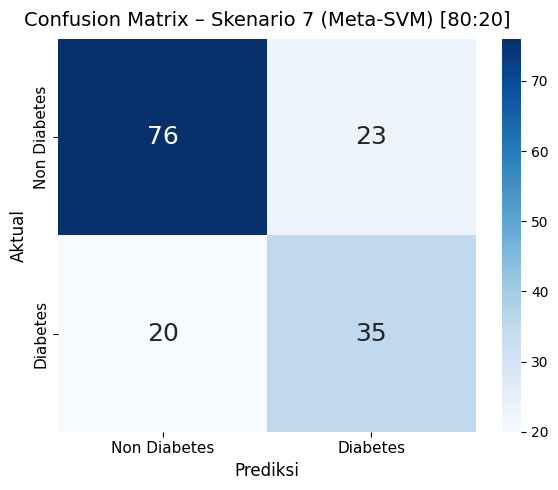

  Hasil Evaluasi Testing – Skenario 7 (Meta-SVM) [80:20]
  Akurasi  : 0.7208
  Presisi  : 0.6034
  Recall   : 0.6364
  F1-Score : 0.6195
waktu_predict_svm_meta_B: 4.69 ms


In [63]:
svm_meta_final_B = grid_svm_meta_B.best_estimator_
import time
_t0 = time.time()
y_pred_svm_meta_B = svm_meta_final_B.predict(X_meta_uji_B)
waktu_predict_svm_meta_B = (time.time() - _t0) * 1000
tampilkan_tabel_perbandingan(y_pred_svm_meta_B, y_test_B, nama_skenario='Skenario 7 [80:20]')
plot_confusion_matrix('Skenario 7 (Meta-SVM) [80:20]', y_test_B, y_pred_svm_meta_B)
hasil_svm_meta_B = evaluasi_testing('Skenario 7 (Meta-SVM) [80:20]', y_test_B, y_pred_svm_meta_B)
print(f'waktu_predict_svm_meta_B: {waktu_predict_svm_meta_B:.2f} ms')

### Skenario 8 Stacking (Meta-ANN) [80:20]

In [64]:
import time
_t0 = time.time()
grid_ann_meta_B = GridSearchCV(
    MLPClassifier(random_state=42),
    param_grid_ann,
    cv=kfold_B, scoring='accuracy', n_jobs=-1, verbose=1,
)
grid_ann_meta_B.fit(X_meta_latih_B, y_meta_latih_B)
print(f'ANN Meta Best Score (80:20): {grid_ann_meta_B.best_score_:.4f}')
print(f'ANN Meta Best Params: {grid_ann_meta_B.best_params_}')
results_ann_meta_B = pd.DataFrame(grid_ann_meta_B.cv_results_)
best_idx = grid_ann_meta_B.best_index_
for fold in range(kfold_B.get_n_splits()):
    fold_score = results_ann_meta_B.loc[best_idx, f'split{fold}_test_score']
    print(f'Fold {fold+1}: {fold_score:.4f}')
print(f'Mean: {grid_ann_meta_B.best_score_:.4f}')
waktu_train_ann_meta_B = (time.time() - _t0) * 1000
print(f'waktu_train_ann_meta_B: {waktu_train_ann_meta_B:.2f} ms')

Fitting 5 folds for each of 72 candidates, totalling 360 fits
ANN Meta Best Score (80:20): 0.8192
ANN Meta Best Params: {'activation': 'tanh', 'hidden_layer_sizes': (50, 50), 'learning_rate_init': 0.001, 'max_iter': 100}
Fold 1: 0.8323
Fold 2: 0.7888
Fold 3: 0.8500
Fold 4: 0.8125
Fold 5: 0.8125
Mean: 0.8192
waktu_train_ann_meta_B: 30441.15 ms


,Prediksi Skenario 8 [80:20](y_pred),Label Aktual(y_test),Keterangan
0,1,0,Tebakan Salah (False Positive)
1,0,0,Tebakan Benar (True Negative)
2,0,0,Tebakan Benar (True Negative)
3,0,0,Tebakan Benar (True Negative)
4,1,0,Tebakan Salah (False Positive)


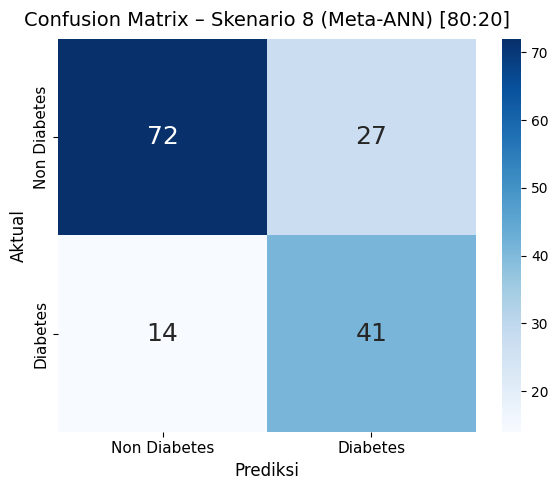

  Hasil Evaluasi Testing – Skenario 8 (Meta-ANN) [80:20]
  Akurasi  : 0.7338
  Presisi  : 0.6029
  Recall   : 0.7455
  F1-Score : 0.6667
waktu_predict_ann_meta_B: 1.20 ms


In [65]:
ann_meta_final_B = grid_ann_meta_B.best_estimator_
import time
_t0 = time.time()
y_pred_ann_meta_B = ann_meta_final_B.predict(X_meta_uji_B)
waktu_predict_ann_meta_B = (time.time() - _t0) * 1000
tampilkan_tabel_perbandingan(y_pred_ann_meta_B, y_test_B, nama_skenario='Skenario 8 [80:20]')
plot_confusion_matrix('Skenario 8 (Meta-ANN) [80:20]', y_test_B, y_pred_ann_meta_B)
hasil_ann_meta_B = evaluasi_testing('Skenario 8 (Meta-ANN) [80:20]', y_test_B, y_pred_ann_meta_B)
print(f'waktu_predict_ann_meta_B: {waktu_predict_ann_meta_B:.2f} ms')

In [66]:
# === TABEL PERBANDINGAN SKENARIO 1-8 (SECTION B: 80:20) ===
hasil_semua_B = [
    hasil_knn_B, hasil_lr_B, hasil_svm_B, hasil_ann_B,
    hasil_knn_meta_B, hasil_lr_meta_B, hasil_svm_meta_B, hasil_ann_meta_B,
]
df_perbandingan_B = pd.DataFrame(hasil_semua_B)
df_perbandingan_B.insert(0, 'Pembagian Data', '80:20')
df_perbandingan_B.index = range(1, len(df_perbandingan_B) + 1)
df_perbandingan_B.index.name = 'No'
print('=== SECTION B (80:20) ===')
display(df_perbandingan_B)
print('\nModel Terbaik per Metrik (80:20):')
for metrik in ['Akurasi', 'Presisi', 'Recall', 'F1-Score']:
    best_idx = df_perbandingan_B[metrik].idxmax()
    best_model = df_perbandingan_B.loc[best_idx, 'Model']
    best_val   = df_perbandingan_B.loc[best_idx, metrik]
    print(f'  {metrik:10s}: {best_model} ({best_val:.4f})')

=== SECTION B (80:20) ===


,Pembagian Data,Model,Akurasi,Presisi,Recall,F1-Score
No,,,,,,
1,80:20,Skenario 1 (KNN) [80:20],0.7208,0.5769,0.8182,0.6767
2,80:20,Skenario 2 (LR) [80:20],0.7208,0.5882,0.7273,0.6504
3,80:20,Skenario 3 (SVM) [80:20],0.7208,0.5909,0.7091,0.6446
4,80:20,Skenario 4 (ANN) [80:20],0.7078,0.5658,0.7818,0.6565
5,80:20,Skenario 5 (Meta-KNN) [80:20],0.7338,0.6129,0.6909,0.6496
6,80:20,Skenario 6 (Meta-LR) [80:20],0.7143,0.5846,0.6909,0.6333
7,80:20,Skenario 7 (Meta-SVM) [80:20],0.7208,0.6034,0.6364,0.6195
8,80:20,Skenario 8 (Meta-ANN) [80:20],0.7338,0.6029,0.7455,0.6667



Model Terbaik per Metrik (80:20):
  Akurasi   : Skenario 5 (Meta-KNN) [80:20] (0.7338)
  Presisi   : Skenario 5 (Meta-KNN) [80:20] (0.6129)
  Recall    : Skenario 1 (KNN) [80:20] (0.8182)
  F1-Score  : Skenario 1 (KNN) [80:20] (0.6767)


---
# 📊 PERBANDINGAN AKHIR: SECTION A (70:30) vs SECTION B (80:20)

=== TABEL GABUNGAN SEMUA SKENARIO (A: 70:30 + B: 80:20) ===


,Pembagian Data,Model,Akurasi,Presisi,Recall,F1-Score
No,,,,,,
1,70:30,Skenario 1 (KNN),0.6537,0.5000,0.6750,0.5745
2,70:30,Skenario 2 (LR),0.6926,0.5385,0.7875,0.6396
3,70:30,Skenario 3 (SVM),0.6667,0.5181,0.5375,0.5276
4,70:30,Skenario 4 (ANN),0.7359,0.5979,0.7250,0.6554
5,70:30,Skenario 5 Stacking (Meta-KNN),0.7100,0.5714,0.6500,0.6082
6,70:30,Skenario 6 Stacking (Meta-lr),0.7056,0.5682,0.6250,0.5952
7,70:30,Skenario 7 Stacking (Meta-SVM),0.7056,0.5682,0.6250,0.5952
8,70:30,Skenario 8 Stacking (Meta-ANN),0.7056,0.5682,0.6250,0.5952
9,80:20,Skenario 1 (KNN) [80:20],0.7208,0.5769,0.8182,0.6767


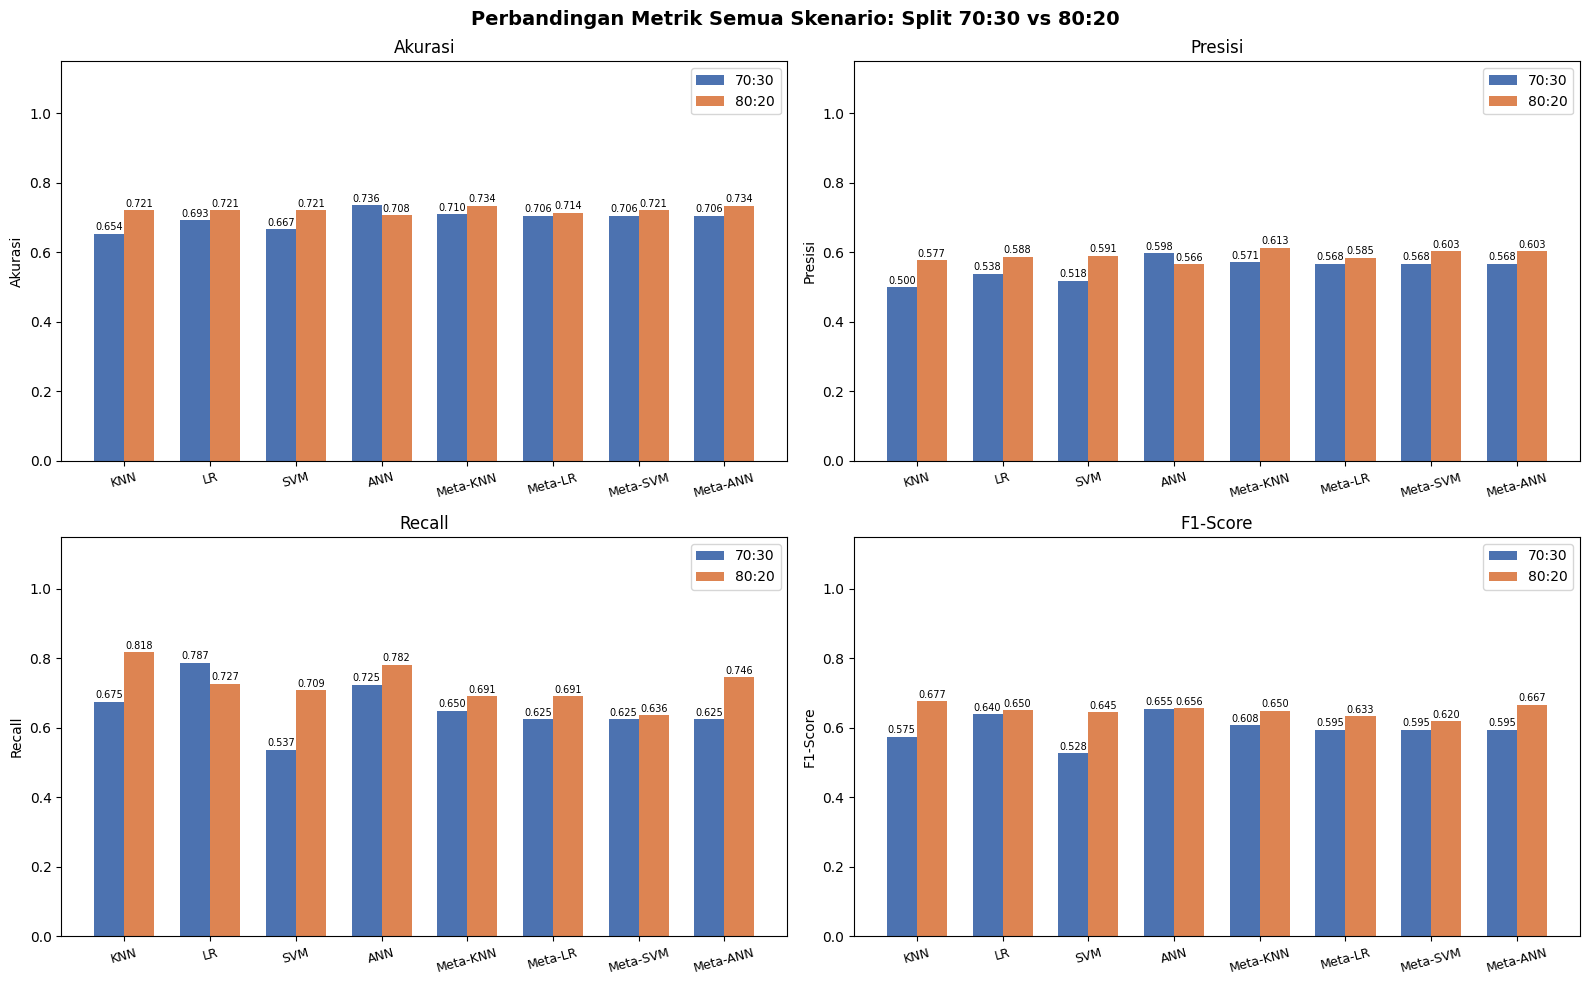


=== RINGKASAN MODEL TERBAIK PER METRIK ===
Metrik       | 70:30 (Model, Nilai)                | 80:20 (Model, Nilai)               
----------------------------------------------------------------------------------------
Akurasi      | Skenario 4 (ANN) (0.7359)           | Skenario 5 (Meta-KNN) [80:20] (0.7338)
Presisi      | Skenario 4 (ANN) (0.5979)           | Skenario 5 (Meta-KNN) [80:20] (0.6129)
Recall       | Skenario 2 (LR) (0.7875)            | Skenario 1 (KNN) [80:20] (0.8182)  
F1-Score     | Skenario 4 (ANN) (0.6554)           | Skenario 1 (KNN) [80:20] (0.6767)  

Tabel perbandingan tersimpan: perbandingan_split_70vs80.xlsx


In [67]:
# ============================================================
# PERBANDINGAN HASIL AKHIR: 70:30 vs 80:20
# ============================================================

# Gabungkan kedua tabel
df_semua = pd.concat([df_perbandingan_A, df_perbandingan_B], ignore_index=True)
df_semua.index = range(1, len(df_semua) + 1)
df_semua.index.name = 'No'
print('=== TABEL GABUNGAN SEMUA SKENARIO (A: 70:30 + B: 80:20) ===')
display(df_semua)

# --- Label bersih untuk visualisasi (tanpa suffix split) ---
import numpy as np
label_bersih = [
    'KNN', 'LR', 'SVM', 'ANN',
    'Meta-KNN', 'Meta-LR', 'Meta-SVM', 'Meta-ANN'
]
x = np.arange(len(label_bersih))
width = 0.35
metriks = ['Akurasi', 'Presisi', 'Recall', 'F1-Score']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, metrik in zip(axes.flatten(), metriks):
    vals_A = df_perbandingan_A[metrik].values
    vals_B = df_perbandingan_B[metrik].values
    bars_A = ax.bar(x - width/2, vals_A, width, label='70:30', color='#4C72B0')
    bars_B = ax.bar(x + width/2, vals_B, width, label='80:20', color='#DD8452')
    ax.set_title(metrik, fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(label_bersih, fontsize=9, rotation=15)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel(metrik)
    ax.legend()
    for bar in bars_A:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', fontsize=7)
    for bar in bars_B:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', fontsize=7)

plt.suptitle('Perbandingan Metrik Semua Skenario: Split 70:30 vs 80:20',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Ringkasan teks: model terbaik tiap split ---
print('\n=== RINGKASAN MODEL TERBAIK PER METRIK ===')
header = f'{"Metrik":12s} | {"70:30 (Model, Nilai)":35s} | {"80:20 (Model, Nilai)":35s}'
print(header)
print('-' * len(header))
for metrik in metriks:
    best_A = df_perbandingan_A.loc[df_perbandingan_A[metrik].idxmax()]
    best_B = df_perbandingan_B.loc[df_perbandingan_B[metrik].idxmax()]
    label_A = f"{best_A['Model']} ({best_A[metrik]:.4f})"
    label_B = f"{best_B['Model']} ({best_B[metrik]:.4f})"
    print(f'{metrik:12s} | {label_A:35s} | {label_B:35s}')

# --- Ekspor ke Excel ---
with pd.ExcelWriter('perbandingan_split_70vs80.xlsx', engine='openpyxl') as writer:
    df_perbandingan_A.to_excel(writer, sheet_name='70-30', index=True)
    df_perbandingan_B.to_excel(writer, sheet_name='80-20', index=True)
    df_semua.to_excel(writer, sheet_name='Gabungan', index=True)
print('\nTabel perbandingan tersimpan: perbandingan_split_70vs80.xlsx')

# EXPORT HASIL KOMBINASI PARAMETER

In [68]:
# import pandas as pd

# def cv_results_to_export(nama_model, results_df):
#     df = results_df[["params", "mean_test_score", "rank_test_score"]].copy()
#     df = df.dropna(subset=["mean_test_score"])

#     df.rename(columns={
#         "params": "Kombinasi Parameter",
#         "mean_test_score": "Rata Rata",
#         "rank_test_score": "Peringkat",
#     }, inplace=True)

#     df.insert(0, "Nama Model", nama_model)
#     df["Kombinasi Parameter"] = df["Kombinasi Parameter"].astype(str)
#     return df

# # =========================
# # BASE (sheet 1)
# # =========================
# df_base = pd.concat([
#     cv_results_to_export("KNN", results_knn),
#     cv_results_to_export("LogReg", results_lr),
#     cv_results_to_export("SVM", results_svm),
#     cv_results_to_export("ANN", results_ann),
# ], ignore_index=True)

# df_base = df_base.sort_values(["Nama Model", "Peringkat"], ascending=[True, True]).reset_index(drop=True)
# df_base.insert(0, "No", range(1, len(df_base) + 1))

# # =========================
# # META (sheet 2)
# # =========================
# df_meta = pd.concat([
#     cv_results_to_export("KNN", results_knn_meta),
#     cv_results_to_export("LogReg", results_logreg_meta),
#     cv_results_to_export("SVM", results_svm_meta),
#     cv_results_to_export("ANN", results_ann_meta),
# ], ignore_index=True)

# df_meta = df_meta.sort_values(["Nama Model", "Peringkat"], ascending=[True, True]).reset_index(drop=True)
# df_meta.insert(0, "No", range(1, len(df_meta) + 1))

# # =========================
# # EXPORT (2 sheet)
# # =========================
# output_excel = "rekap_kombinasi_parameter_base_dan_meta.xlsx"
# with pd.ExcelWriter(output_excel, engine="openpyxl") as writer:
#     df_base.to_excel(writer, index=False, sheet_name="Base")
#     df_meta.to_excel(writer, index=False, sheet_name="Meta")

# print("Berhasil membuat:", output_excel)
# print("Total baris Base:", len(df_base))
# print("Total baris Meta:", len(df_meta))

# OUTPUT PELATIHAN MODEL

### KNN

In [69]:
# print(f"Metrik Jarak: {knn_final.effective_metric_}")
# print(f"Jumlah Sampel Latihan: {knn_final.n_samples_fit_}")

## LR

In [70]:
# print(f"Koefisien (Bobot): \n{lr_final.coef_}")
# print(f"Intercept (Bias): {lr_final.intercept_}")
# print(f"Jumlah Iterasi: {lr_final.n_iter_}")

## SVM

In [71]:
# print(f"Indeks Support Vectors: {svm_final.support_}")
# print(f"Jumlah Support Vectors per kelas: {svm_final.n_support_[0]} (kelas 0), {svm_final.n_support_[1]} (kelas 1)")
# print(f"Konstanta Bias (intercept_): {svm_final.intercept_}")
# print(f"Total Support Vectors: {sum(svm_final.n_support_)}")

In [72]:
# n_fitur = X_train_smote.shape[1]
# gamma_auto = 1 / n_fitur
# print(gamma_auto)

In [73]:
# X_var = X_train_smote.to_numpy().var()
# print(X_var)
# gamma_scale = 1/(n_fitur * X_var)
# print(f"Gamma Scale: {gamma_scale:.4f}")

## ANN

In [74]:
# # Hasil pelatihan ANN
# print(ann_final.loss_)
# print(ann_final.n_iter_)
# print(ann_final.t_)
# print(ann_final.n_layers_)
# print(ann_final.n_outputs_)
# print(ann_final.out_activation_)
# print(f"\nShape Matriks Bobot (coefs_): {[c.shape for c in ann_final.coefs_]}")
# print(f"Shape Vektor Bias (intercepts_): {[i.shape for i in ann_final.intercepts_]}")

In [75]:
# import matplotlib.pyplot as plt

# # 1. Mengambil data loss_curve_ dari model yang sudah dilatih
# loss_values = ann_final.loss_curve_

# # 2. Membuat plot
# plt.figure(figsize=(10, 6))
# plt.plot(loss_values, label='Loss (Error)', color='tab:orange', linewidth=2)

# # 3. Menambahkan label dan judul untuk kebutuhan Skripsi
# plt.title('Grafik Konvergensi Loss (Epoch) Skenario 4', fontsize=14)
# plt.xlabel('Iterasi (Epoch)', fontsize=12)
# plt.ylabel('Nilai Loss', fontsize=12)

# # 4. Menandai titik akhir (konvergensi)
# plt.scatter(len(loss_values)-1, loss_values[-1], color='red')
# plt.text(len(loss_values)-1, loss_values[-1], f' Loss Akhir: {loss_values[-1]:.4f}',
#          verticalalignment='bottom', horizontalalignment='right')

# # 5. Mempercantik tampilan
# plt.grid(True, linestyle='--', alpha=0.7)
# plt.legend()
# plt.show()

## KNN-META

In [76]:
# print(f"Metrik Jarak: {knn_meta_final.effective_metric_}")
# print(f"Jumlah Sampel Latihan: {knn_meta_final.n_samples_fit_}")

## LR-META

In [77]:
# print(f"Koefisien (Bobot): \n{logreg_meta_final.coef_}")
# print(f"Intercept (Bias): {logreg_meta_final.intercept_}")
# print(f"Jumlah Iterasi: {logreg_meta_final.n_iter_}")

## SVM-META

In [78]:
# print(f"Indeks Support Vectors: {svm_meta_final.support_}")
# print(f"Jumlah Support Vectors per kelas: {svm_meta_final.n_support_}")
# print(f"Konstanta Bias (intercept_): {svm_meta_final.intercept_}")

In [79]:
# n_fitur = X_meta_latih.shape[1]
# gamma_auto = 1 / n_fitur
# print(gamma_auto)

In [80]:
# X_var = X_meta_latih.to_numpy().var()
# print(X_var)
# gamma_scale = 1/(n_fitur * X_var)
# print(f"Gamma Scale: {gamma_scale:.4f}")

## ANN-META

In [81]:
# # Hasil pelatihan ANN
# print(ann_meta_final.loss_)
# print(ann_meta_final.n_iter_)
# print(ann_meta_final.t_)
# print(ann_meta_final.n_layers_)
# print(ann_meta_final.n_outputs_)
# print(ann_meta_final.out_activation_)
# print(f"\nShape Matriks Bobot (coefs_): {[c.shape for c in ann_meta_final.coefs_]}")
# print(f"Shape Vektor Bias (intercepts_): {[i.shape for i in ann_meta_final.intercepts_]}")

In [82]:
# import matplotlib.pyplot as plt

# # 1. Mengambil data loss_curve_ dari model yang sudah dilatih
# loss_values = ann_meta_final.loss_curve_

# # 2. Membuat plot
# plt.figure(figsize=(10, 6))
# plt.plot(loss_values, label='Loss (Error)', color='tab:orange', linewidth=2)

# # 3. Menambahkan label dan judul untuk kebutuhan Skripsi
# plt.title('Grafik Konvergensi Loss (Epoch) Skenario 8', fontsize=14)
# plt.xlabel('Iterasi (Epoch)', fontsize=12)
# plt.ylabel('Nilai Loss', fontsize=12)

# # 4. Menandai titik akhir (konvergensi)
# plt.scatter(len(loss_values)-1, loss_values[-1], color='red')
# plt.text(len(loss_values)-1, loss_values[-1], f' Loss Akhir: {loss_values[-1]:.4f}',
#          verticalalignment='bottom', horizontalalignment='right')

# # 5. Mempercantik tampilan
# plt.grid(True, linestyle='--', alpha=0.7)
# plt.legend()
# plt.show()

# SIMPAN MODEL UNTUK DEPLOYMENT

In [83]:
# import numpy as np

# def ekstrak_info_grid(nama_model, grid_obj, kfold_obj):
#     """
#     Ekstrak info GridSearchCV secara dinamis.
#     Tidak ada hardcode — semua diambil dari objek hasil fit.
#     """
#     results_df = pd.DataFrame(grid_obj.cv_results_)
#     best_idx   = grid_obj.best_index_
#     n_splits   = kfold_obj.get_n_splits()

#     fold_scores = [
#         float(results_df.loc[best_idx, f"split{k}_test_score"])
#         for k in range(n_splits)
#     ]

#     # Konversi best_params agar JSON-serializable (np.float64 → float, tuple → list)
#     def to_json_safe(v):
#         if isinstance(v, (np.integer,)):  return int(v)
#         if isinstance(v, (np.floating,)): return float(v)
#         if isinstance(v, tuple):          return list(v)
#         return v

#     best_params_safe = {k: to_json_safe(v) for k, v in grid_obj.best_params_.items()}

#     return {
#         "model"      : nama_model,
#         "cv"         : {
#             "n_folds"     : n_splits,
#             "n_candidates": len(results_df),
#             "total_fits"  : n_splits * len(results_df),
#         },
#         "best_score" : round(float(grid_obj.best_score_), 4),
#         "best_params": best_params_safe,
#         "fold_scores": [round(s, 4) for s in fold_scores],
#         "mean"       : round(float(grid_obj.best_score_), 4),
#     }


# def simpan_model_dan_info(nama_file, nama_model, model_obj, grid_obj, kfold_obj, out_dir):
#     """
#     Simpan model (.joblib) + info (.json) secara dinamis.
#     nama_file : prefix file, misal 'knn' → knn_model.joblib & knn_info.json
#     """
#     out_dir = Path(out_dir)
#     out_dir.mkdir(parents=True, exist_ok=True)

#     # Simpan model
#     joblib.dump(model_obj, out_dir / f"{nama_file}_model.joblib")

#     # Buat & simpan info
#     info = ekstrak_info_grid(nama_model, grid_obj, kfold_obj)
#     with open(out_dir / f"{nama_file}_info.json", "w", encoding="utf-8") as f:
#         json.dump(info, f, indent=2, ensure_ascii=False)

#     print(f"[OK] {nama_file}_model.joblib & {nama_file}_info.json tersimpan")
#     return info

# print("Fungsi simpan_model_dan_info siap digunakan.")

## Simpan Semua Model Base Learner

In [84]:
# out_dir = "for_deployment"

# knn_info      = simpan_model_dan_info("knn",  "KNN",               knn_final,         grid_knn,        kfold, out_dir)
# lr_info       = simpan_model_dan_info("lr",   "LogisticRegression", lr_final,          grid_lr,         kfold, out_dir)
# svm_info      = simpan_model_dan_info("svm",  "SVM",               svm_final,         grid_svm,        kfold, out_dir)
# ann_info      = simpan_model_dan_info("ann",  "ANN",               ann_final,         grid_ann,        kfold, out_dir)

## Simpan Semua Model Meta Learner

In [85]:
# knn_meta_info  = simpan_model_dan_info("knn_meta",    "KNN_META",     knn_meta_final,    grid_knn_meta,    kfold, out_dir)
# lr_meta_info   = simpan_model_dan_info("logreg_meta", "LogReg_META",  logreg_meta_final, grid_logreg_meta, kfold, out_dir)
# svm_meta_info  = simpan_model_dan_info("svm_meta",    "SVM_META",     svm_meta_final,    grid_svm_meta,    kfold, out_dir)
# ann_meta_info  = simpan_model_dan_info("ann_meta",    "ANN_META",     ann_meta_final,    grid_ann_meta,    kfold, out_dir)

# PERBANDINGAN WAKTU KOMPUTASI ANTAR SKENARIO

In [86]:
# # Waktu training stacking = waktu buat dataset_training_meta + waktu fit meta learner
# # Waktu predict stacking   = waktu buat dataset_testing_meta  + waktu predict meta learner

# data_waktu = [
#     {
#         "Skenario"         : "Skenario 1 (KNN)",
#         "Waktu Training (ms)": round(waktu_train_knn, 2),
#         "Waktu Prediksi (ms)": round(waktu_predict_knn, 2),
#     },
#     {
#         "Skenario"         : "Skenario 2 (LR)",
#         "Waktu Training (ms)": round(waktu_train_lr, 2),
#         "Waktu Prediksi (ms)": round(waktu_predict_lr, 2),
#     },
#     {
#         "Skenario"         : "Skenario 3 (SVM)",
#         "Waktu Training (ms)": round(waktu_train_svm, 2),
#         "Waktu Prediksi (ms)": round(waktu_predict_svm, 2),
#     },
#     {
#         "Skenario"         : "Skenario 4 (ANN)",
#         "Waktu Training (ms)": round(waktu_train_ann, 2),
#         "Waktu Prediksi (ms)": round(waktu_predict_ann, 2),
#     },
#     {
#         "Skenario"         : "Skenario 5 Stacking (Meta-KNN)",
#         # training  = pengumpulan dataset training meta + fit meta learner
#         "Waktu Training (ms)": round(waktu_buat_dataset_training_meta + waktu_train_knn_meta, 2),
#         # prediksi  = pengumpulan dataset testing meta + predict meta learner
#         "Waktu Prediksi (ms)": round(waktu_buat_dataset_testing_meta  + waktu_predict_knn_meta, 2),
#     },
#     {
#         "Skenario"         : "Skenario 6 Stacking (Meta-LR)",
#         "Waktu Training (ms)": round(waktu_buat_dataset_training_meta + waktu_train_lr_meta, 2),
#         "Waktu Prediksi (ms)": round(waktu_buat_dataset_testing_meta  + waktu_predict_lr_meta, 2),
#     },
#     {
#         "Skenario"         : "Skenario 7 Stacking (Meta-SVM)",
#         "Waktu Training (ms)": round(waktu_buat_dataset_training_meta + waktu_train_svm_meta, 2),
#         "Waktu Prediksi (ms)": round(waktu_buat_dataset_testing_meta  + waktu_predict_svm_meta, 2),
#     },
#     {
#         "Skenario"         : "Skenario 8 Stacking (Meta-ANN)",
#         "Waktu Training (ms)": round(waktu_buat_dataset_training_meta + waktu_train_ann_meta, 2),
#         "Waktu Prediksi (ms)": round(waktu_buat_dataset_testing_meta  + waktu_predict_ann_meta, 2),
#     },
# ]

# df_waktu = pd.DataFrame(data_waktu)
# df_waktu

In [87]:
# # Visualisasi perbandingan waktu komputasi
# fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# warna = [
#     "#4C72B0", "#4C72B0", "#4C72B0", "#4C72B0",  # base learner — biru
#     "#DD8452", "#DD8452", "#DD8452", "#DD8452",  # stacking — oranye
# ]
# skenario_labels = [s.replace("Skenario ", "S").replace(" Stacking", "\nStacking") for s in df_waktu["Skenario"]]

# # Waktu Training
# axes[0].bar(skenario_labels, df_waktu["Waktu Training (ms)"], color=warna)
# axes[0].set_title("Waktu Training per Skenario", fontsize=13)
# axes[0].set_ylabel("Waktu (ms)")
# axes[0].set_xlabel("Skenario")
# axes[0].tick_params(axis="x", labelsize=8)
# for i, v in enumerate(df_waktu["Waktu Training (ms)"]):
#     axes[0].text(i, v + 0.5, f"{v:.0f}", ha="center", fontsize=7)

# # Waktu Prediksi
# axes[1].bar(skenario_labels, df_waktu["Waktu Prediksi (ms)"], color=warna)
# axes[1].set_title("Waktu Prediksi per Skenario", fontsize=13)
# axes[1].set_ylabel("Waktu (ms)")
# axes[1].set_xlabel("Skenario")
# axes[1].tick_params(axis="x", labelsize=8)
# for i, v in enumerate(df_waktu["Waktu Prediksi (ms)"]):
#     axes[1].text(i, v + 0.1, f"{v:.2f}", ha="center", fontsize=7)

# # Legend manual
# from matplotlib.patches import Patch
# legend_elements = [Patch(facecolor="#4C72B0", label="Base Learner"),
#                    Patch(facecolor="#DD8452", label="Stacking")]
# fig.legend(handles=legend_elements, loc="upper right", fontsize=10)

# plt.suptitle("Perbandingan Waktu Komputasi Antar Skenario", fontsize=14, fontweight="bold")
# plt.tight_layout()
# plt.show()

In [88]:
# # Ekspor tabel waktu komputasi ke Excel
# df_waktu.to_excel("waktu_komputasi_skenario.xlsx", index=False)
# print("Tabel waktu komputasi tersimpan: waktu_komputasi_skenario.xlsx")

## Bedah Model

### KNN S1

In [89]:
# import numpy as np
# import pandas as pd
# from IPython.display import display

# # 1. Hitung jarak dan probabilitas untuk seluruh data testing
# distances_all, indices_all = knn_final.kneighbors(X_test)
# prob_all = knn_final.predict_proba(X_test)[:, 1]

# # 2. Filter data secara ketat
# valid_indices = []
# for i in range(len(distances_all)):
#     dists = distances_all[i]
#     prob = prob_all[i]

#     # Syarat 1: Probabilitas BUKAN 0.0 dan BUKAN 1.0 (Harus ada campuran kelas tetangga)
#     if prob == 0.0 or prob == 1.0:
#         continue

#     # Syarat 2: Jarak pertama tidak boleh 0.0000
#     if dists[0] == 0:
#         continue

#     # Syarat 3: Jarak harus bervariasi (minimal 4 jarak berbeda dari 5 tetangga)
#     unique_dists = np.unique(dists)
#     if len(unique_dists) >= 4:
#         valid_indices.append(i)

# valid_indices = np.array(valid_indices)

# # 3. Ambil 5 sampel acak dari daftar yang sudah difilter
# if len(valid_indices) < 5:
#     print(f"Catatan: Hanya ditemukan {len(valid_indices)} data yang memenuhi syarat ketat ini.")
#     sample_idx = valid_indices
# else:
#     np.random.seed(42) # Angka seed agar hasilnya tetap sama jika di-run ulang
#     sample_idx = np.random.choice(valid_indices, 5, replace=False)

# # 4. Ambil data sampel berdasarkan indeks yang terpilih
# X_sample = X_test.values[sample_idx] if hasattr(X_test, 'values') else X_test[sample_idx]
# y_sample_asli = y_test.values[sample_idx] if hasattr(y_test, 'values') else y_test[sample_idx]
# index_sample = y_test.index[sample_idx] if hasattr(y_test, 'index') else sample_idx

# # 5. Dapatkan jarak dan indeks 5 tetangga terdekat khusus
# distances = distances_all[sample_idx]
# indices = indices_all[sample_idx]

# # 6. Dapatkan probabilitas (Kelas 0 dan 1) dan prediksi akhir
# prob_library = knn_final.predict_proba(X_sample)
# pred_library = knn_final.predict(X_sample)

# # 7. Ambil label asli dari data training untuk mengetahui kelas tetangga
# y_train_array = y_train_smote.values if hasattr(y_train_smote, 'values') else y_train_smote

# # 8. Susun data menjadi DataFrame
# data_tabel = []
# for i in range(len(X_sample)):
#     row_data = {
#         # 'Urutan di Data Uji': sample_idx[i],
#         # 'Index': index_sample[i]
#     }

#     # Memasukkan jarak dan kelas untuk masing-masing ke-5 tetangga
#     for k in range(5):
#         dist = distances[i][k]
#         kelas_tetangga = y_train_array[indices[i][k]]
#         row_data[f'Tetangga {k+1}'] = f"{dist:.4f} (K:{kelas_tetangga})"

#     # Memasukkan hasil probabilitas Kelas 0, Kelas 1, dan Prediksi
#     # row_data['Probabilitas Kelas 0'] = round(prob_library[i][0], 5)
#     # row_data['Probabilitas Kelas 1'] = round(prob_library[i][1], 5)
#     row_data['Prediksi Model'] = pred_library[i]
#     row_data['Label Asli'] = y_sample_asli[i]

#     data_tabel.append(row_data)

# df_knn_sempurna = pd.DataFrame(data_tabel)

# print("--- DETAIL JARAK TETANGGA (VARIAN JARAK & PROBABILITAS CAMPURAN) ---")
# display(df_knn_sempurna)

### LR S2

In [90]:
# import numpy as np
# import pandas as pd
# from IPython.display import display

# # 1. Pastikan data testing berbentuk matriks angka
# X_test_array = X_test.values if hasattr(X_test, 'values') else X_test

# # 2. Ambil koefisien (w) dan intercept (b)
# w = lr_final.coef_[0]
# b = lr_final.intercept_[0]

# # 3. KALKULASI MATEMATIS MANUAL
# # Hitung kombinasi linear (z) = w*x + b
# z_manual = np.dot(X_test_array, w) + b

# # Hitung f(x) menggunakan rumus Sigmoid
# fx_manual = 1 / (1 + np.exp(-z_manual))

# # Probabilitas Kelas 1 dan Kelas 0
# p_manual_1 = fx_manual
# p_manual_0 = 1 - p_manual_1

# # 4. KEPUTUSAN PREDIKSI (Berdasarkan teori ambang batas > 0.5)
# # Jika fx_manual >= 0.5, maka hasilnya 1. Jika tidak, hasilnya 0.
# prediksi_manual = (fx_manual >= 0.5).astype(int)

# # 5. SUSUN TABEL MANUAL
# df_manual = pd.DataFrame({

#     'Hasil z': z_manual.round(5),
#     'Hasil f(x)': fx_manual.round(5),
#     'Prediksi Model': prediksi_manual,
#     'Label Asli': y_test.values if hasattr(y_test, 'values') else y_test,
# })

# print("--- BUKTI PERHITUNGAN MATEMATIS MANUAL ---")
# display(df_manual.head(5))

### SVM S3

In [91]:
# import numpy as np
# import pandas as pd
# from IPython.display import display

# # 1. Pastikan data berformat array
# X_test_array = X_test.values if hasattr(X_test, 'values') else X_test

# # 2. Ekstrak parameter matematis dari model SVM RBF Anda
# SVs = svm_final.support_vectors_       # Koordinat titik Support Vectors
# dual_coefs = svm_final.dual_coef_[0]   # Koefisien dual (Alpha * y)
# b = svm_final.intercept_[0]            # Nilai bias (konstanta)
# gamma = svm_final._gamma            # Nilai gamma dari kernel RBF

# # 3. KALKULASI MATEMATIS FUNGSI KEPUTUSAN UNTUK SELURUH DATA TESTING
# fx_list = []
# prediksi_list = []

# for sample_x in X_test_array:
#     # a. Hitung kuadrat jarak (Euclidean) ke semua Support Vectors
#     sq_distances = np.sum((SVs - sample_x) ** 2, axis=1)

#     # b. Fungsi Kernel RBF
#     K = np.exp(-gamma * sq_distances)

#     # c. Fungsi Keputusan f(x)
#     fx = np.dot(dual_coefs, K) + b
#     fx_list.append(fx)

#     # d. Aturan Keputusan SVM (Threshold 0)
#     prediksi = 1 if fx >= 0 else 0
#     prediksi_list.append(prediksi)

# # 4. SUSUN TABEL HASIL MATEMATIS
# df_matematis = pd.DataFrame({
#     'f(x)': np.round(fx_list, 5),
#     'Prediksi Model': prediksi_list,
#     'Label Asli': y_test.values if hasattr(y_test, 'values') else y_test,
# })

# print("--- HASIL PERHITUNGAN MATEMATIS FUNGSI KEPUTUSAN SVM ---")
# display(df_matematis.head(5))

### ANN S4

In [92]:

# from IPython.display import display

# # 1. Pastikan data berformat array
# X_test_array = X_test.values if hasattr(X_test, 'values') else X_test

# # 2. Ekstrak matriks bobot (W) dan bias (b) dari model ANN
# W1, W2, W3 = ann_final.coefs_
# b1, b2, b3 = ann_final.intercepts_

# # 3. PROSES FORWARD PROPAGATION MANUAL
# # --- Langkah 1: Input ke Hidden Layer 1 ---
# # Z1 = (X * W1) + b1
# Z1 = np.dot(X_test_array, W1) + b1
# # Fungsi Aktivasi ReLU: max(0, Z)
# A1 = np.maximum(0, Z1)

# # --- Langkah 2: Hidden Layer 1 ke Hidden Layer 2 ---
# # Z2 = (A1 * W2) + b2
# Z2 = np.dot(A1, W2) + b2
# # Fungsi Aktivasi ReLU
# A2 = np.maximum(0, Z2)

# # --- Langkah 3: Hidden Layer 2 ke Output Layer ---
# # Z3 = (A2 * W3) + b3
# Z3 = np.dot(A2, W3) + b3
# # Karena matriks hasil ukurannya (N, 1), kita ratakan (flatten) jadi 1 dimensi
# Z3 = Z3.flatten()

# # Fungsi Aktivasi Output: Logistic (Sigmoid)
# p_manual_1 = 1 / (1 + np.exp(-Z3))
# p_manual_0 = 1 - p_manual_1



# # 5. SUSUN TABEL KOMPARASI
# df_ann_komparasi = pd.DataFrame({
#     'Probabilitas Kelas 1 (Manual Forward Prop)': p_manual_1.round(6),
# })


# display(df_ann_komparasi.head(15))

### META-KNN S5

In [93]:
# import numpy as np
# import pandas as pd
# from IPython.display import display

# # 1. Hitung jarak dan indeks untuk seluruh data meta-features uji
# distances_all, indices_all = knn_meta_final.kneighbors(X_meta_uji)
# pred_all = knn_meta_final.predict(X_meta_uji)
# y_train_meta_array = y_meta_latih.values if hasattr(y_meta_latih, 'values') else y_meta_latih

# # 2. Filter khusus: Cari data yang komposisi 13 tetangganya BERCAMPUR (Heterogen)
# valid_indices = []
# for i in range(len(distances_all)):
#     inds = indices_all[i]
#     kelas_tetangga = y_train_meta_array[inds]

#     # Menghitung berapa banyak Kelas 0 dan Kelas 1 di antara 13 tetangga
#     count_k0 = np.sum(kelas_tetangga == 0)
#     count_k1 = np.sum(kelas_tetangga == 1)

#     # Syarat Campuran: Minimal ada 3 tetangga dari kelas yang berbeda (tidak boleh 13-0 atau 12-1)
#     if count_k0 >= 3 and count_k1 >= 3:
#         # Syarat tambahan: Jarak tidak boleh nol (bukan duplikat)
#         if distances_all[i][0] > 0:
#             valid_indices.append(i)

# valid_indices = np.array(valid_indices)

# # 3. Ambil 5 sampel dari hasil filter
# if len(valid_indices) < 5:
#     print(f"Hanya ditemukan {len(valid_indices)} data dengan tetangga campuran. Mengambil semua yang ada.")
#     sample_idx = valid_indices
# else:
#     np.random.seed(10) # Seed diubah agar mendapat variasi baru
#     sample_idx = np.random.choice(valid_indices, 5, replace=False)

# # 4. Susun data secara vertikal
# y_sample_asli = y_meta_uji.values[sample_idx] if hasattr(y_meta_uji, 'values') else y_meta_uji[sample_idx]
# data_tabel = {}

# for i in range(len(sample_idx)):
#     col_name = f"Data uji {i+1}"
#     row_values = []

#     dists = distances_all[sample_idx[i]]
#     inds = indices_all[sample_idx[i]]

#     for k in range(11):
#         row_values.append(f"{dists[k]:.4f} (K:{y_train_meta_array[inds[k]]})")

#     row_values.append(int(pred_all[sample_idx[i]]))
#     row_values.append(int(y_sample_asli[i]))

#     data_tabel[col_name] = row_values

# indeks_baris = [f"Tetangga {i+1}" for i in range(11)] + ["PREDIKSI META", "LABEL ASLI"]
# df_vertikal = pd.DataFrame(data_tabel, index=indeks_baris)

# print("--- DETAIL 13 TETANGGA (KOMPOSISI CAMPURAN/HETEROGEN) ---")
# display(df_vertikal)

### META-LR S6

In [94]:
# import numpy as np
# import pandas as pd
# from IPython.display import display

# # 1. Pastikan data testing berbentuk matriks angka
# X_test_array = X_meta_uji.values if hasattr(X_meta_uji, 'values') else X_meta_uji

# # 2. Ambil koefisien (w) dan intercept (b)
# w = logreg_meta_final.coef_[0]
# b = logreg_meta_final.intercept_[0]

# # 3. KALKULASI MATEMATIS MANUAL
# # Hitung kombinasi linear (z) = w*x + b
# z_manual = np.dot(X_test_array, w) + b

# # Hitung f(x) menggunakan rumus Sigmoid
# fx_manual = 1 / (1 + np.exp(-z_manual))

# # Probabilitas Kelas 1 dan Kelas 0
# p_manual_1 = fx_manual
# p_manual_0 = 1 - p_manual_1

# # 4. KEPUTUSAN PREDIKSI (Berdasarkan teori ambang batas > 0.5)
# # Jika fx_manual >= 0.5, maka hasilnya 1. Jika tidak, hasilnya 0.
# prediksi_manual = (fx_manual >= 0.5).astype(int)

# # 5. SUSUN TABEL MANUAL
# df_manual = pd.DataFrame({
#     'Hasil z': z_manual.round(5),
#     'Hasil f(x)': fx_manual.round(5),
#     'Prediksi Model': prediksi_manual,
#     'Label Asli': y_test.values if hasattr(y_test, 'values') else y_test,
# })

# print("--- BUKTI PERHITUNGAN MATEMATIS MANUAL ---")
# display(df_manual.head(5))

### META-SVM S7

In [95]:
# import numpy as np
# import pandas as pd
# from IPython.display import display

# # 1. Pastikan data berformat array (menggunakan meta-features uji)
# X_meta_uji_array = X_meta_uji.values if hasattr(X_meta_uji, 'values') else X_meta_uji

# # 2. Ekstrak parameter matematis dari model SVM Linear
# # meta_svm_final adalah nama variabel model SVM Stacking Anda
# w = svm_meta_final.coef_[0]      # Koefisien bobot fitur meta
# b = svm_meta_final.intercept_[0] # Nilai bias

# # 3. KALKULASI MATEMATIS FUNGSI KEPUTUSAN (Linear: f(x) = Xw + b)
# # Kita bisa menggunakan np.dot untuk perkalian matriks yang lebih cepat
# fx_list = np.dot(X_meta_uji_array, w) + b

# # 4. Aturan Keputusan (Threshold 0)
# prediksi_list = [1 if fx >= 0 else 0 for fx in fx_list]

# # 5. SUSUN TABEL HASIL MATEMATIS
# df_matematis_svm = pd.DataFrame({
#     'Nilai Jarak f(x)': np.round(fx_list, 5),
#     'Prediksi Model': prediksi_list,
#     'Label Asli': y_meta_uji.values if hasattr(y_meta_uji, 'values') else y_meta_uji
# })

# print("--- HASIL PERHITUNGAN MATEMATIS FUNGSI KEPUTUSAN META-SVM (LINEAR) ---")
# display(df_matematis_svm.head(15))

### ANN-META S8

In [96]:
# import pandas as pd
# import numpy as np
# from IPython.display import display

# # 1. Menentukan jumlah data testing yang tersedia
# n_total = len(X_meta_uji)

# # 2. Mengambil 5 nomor urut posisi secara acak (misal: urutan ke-10, ke-50, dst)
# np.random.seed(42) # Agar hasil acak tetap sama setiap kali dijalankan
# random_pos = np.random.choice(n_total, 5, replace=False)

# # 3. Mengambil data berdasarkan POSISI (iloc), bukan berdasarkan LABEL indeks
# # Ini akan menghindari KeyError
# X_meta_sample = X_meta_uji.iloc[random_pos]
# y_sample_asli = y_meta_uji.iloc[random_pos]

# # 4. Mendapatkan probabilitas dan prediksi dari model
# prob_meta_ann = ann_meta_final.predict_proba(X_meta_sample)
# pred_meta_ann = ann_meta_final.predict(X_meta_sample)

# # 5. Menyusun ke dalam DataFrame untuk Tabel Skripsi
# df_meta_ann_output = pd.DataFrame({
#     'Hasil Output Layer': prob_meta_ann[:, 1].round(5),
#     'Prediksi Model': pred_meta_ann,
#     'Label Asli': y_sample_asli.values
# })

# # 6. Reset indeks agar tampil rapi 0-4
# df_meta_ann_output = df_meta_ann_output.reset_index(drop=True)

# print("--- 5 SAMPEL DATA TESTING (PROSES POSISI ILOC) ---")
# display(df_meta_ann_output)